# Soil Moisture Forecasting with ConvLSTM

## 1. Problem Description

- **Task**:
    Predict future soil moisture (`sm_30cm`) using past observations.

- **Input**:
    Multivariate daily time series (len(features) variables).

- **Output**:
    Soil moisture at a specific depth for the next `horizon` days.

- **Data structure**:
    Multiple CSV files, each containing data from one region, further divided by `probe_name`.

---

## 2. Input Variables

Each daily record contains the following **7 input variables**:

## 3. Model Input / Output Definition

### Input (X)

For each sample, the model receives:

- The past **`window` days** of observations
- Shape:
X.shape = (N_samples, window, 1, 7, 1)

This follows the ConvLSTM2D input format: (batch, time, rows, cols, channels)

Where:
- `window` = lookback length (e.g. 14 or 30 days)
- `7` = number of input variables

---

### Output (Y)

- Prediction for the requested horizon
- Shape:

Y.shape = (N_samples, horizon)

- Represents soil moisture (`sm_xcm`) for the next day(s).

## ConvLSTM 
Flatten 7 variables into a 1x7x1 "pseudo-spatial grid"

Input shape: (batch, time, 1, 7, 1)

Output: (batch, horizon) of sm_30cm(t+1 to t+horizon)

Spatial split (by files/stations): train/val/test = 70%/15%/15%

Train with train, early stop / adjust learning rate with val

Evaluate metrics (MAE / RMSE) on test

Output simultaneously: sm_30cm prediction for the next day (t+1) after the last date in each test file

In [53]:
%pip install optuna

In [54]:
import os
import re
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import optuna

from typing import Dict, Tuple, List

from sklearn.preprocessing import StandardScaler
from sklearn.multioutput import MultiOutputRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

import tensorflow as tf
from xgboost import XGBRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
import lightgbm as lgb
from tensorflow.keras import layers, models, callbacks
from tensorflow.keras.models import load_model
from tensorflow.keras.losses import MeanSquaredError
from tensorflow.keras.metrics import MeanSquaredError as MSE
from tensorflow.keras.regularizers import l2

In [55]:
# mount drive if colab
from google.colab import drive
drive.mount('/content/gdrive')

Drive already mounted at /content/gdrive; to attempt to forcibly remount, call drive.mount("/content/gdrive", force_remount=True).


In [56]:
# ============================================================
# Configuration
# ============================================================

ROOT_DIR = "/content/gdrive/MyDrive/NIFA_Download/dataset_training"
FOLDER_NAME = "csv_meteo_and_soil"    
base_path = os.path.join(ROOT_DIR, FOLDER_NAME, "depth")


DENSE_FEATURE_COLS = [
    # "soil_moisture", 
    "IRRAD", "TMIN", "TMAX", "VAP", "WIND", "RAIN",

                      "clay_m_30m_0cm_30cm", "silt_m_30m_0cm_30cm",
                      "bulk_m_30m_0cm_30cm", "ksat_m_1km_0cm",
                      "dem_aspect", "dem_twi"] # + doy_sin_cos pour la saisonnalité

SPARSE_FEATURE_COLS = []
    # "S1_VV", "S1_VH", "S2_B2", "S2_B3", "S2_B4", "S2_B5", "S2_B6", "S2_B7", "S2_B8", "S2_B8A", "S2_B11", "S2_B12", "S2_NDVI"
    # ]

MASK_COLS = []
# "S1_VV_mask", "S1_VH_mask", "S2_B2_mask", "S2_B3_mask", "S2_B4_mask", "S2_B5_mask", "S2_B6_mask", "S2_B7_mask", "S2_B8_mask", "S2_B8A_mask", "S2_B11_mask", "S2_B12_mask", "S2_NDVI_mask"]

FEATURE_COLS = DENSE_FEATURE_COLS + SPARSE_FEATURE_COLS + MASK_COLS
#    ["soil_moisture", "IRRAD", "TMIN", "TMAX", "VAP", "WIND", "RAIN",
# "dem_m_30m_depth", "clay_m_30m_0cm_30cm", "silt_m_30m_0cm_30cm", "sand_m_30m_0cm_30cm", "Saturation",
# "bulk_m_30m_0cm_30cm", "ksat_m_1km_0cm", "dem_slope", "dem_aspect", "dem_twi"] 
# S2_B2	S2_B3	S2_B4	S2_B5	S2_B6	S2_B7	S2_B8	S2_B8A	S2_B11	S2_B12	S2_NDVI	
# S1_VV	S1_VH	S1_angle	
# HLS_B2	HLS_B3	HLS_B4	HLS_B5	HLS_B6	HLS_B7	HLS_B9	HLS_B10	HLS_B11	HLS_NDVI

TARGET_COL = "soil_moisture"
DATE_COL = "DateTime"  # L'index temporel est sauvegardé sous DateTime par process_timeseries

TRAIN_RATIO = 0.70
VAL_RATIO = 0.15           # remaining 0.15 is test

# Training settings
HORIZONS = [7]              # predict * days ahead 
LOOKBACK = [7] #, 14]              # use past * days to predict next day
EPOCHS = 150
BATCH_SIZE = 32
SEED = 8
DEPTHS = [0.1]  # we will loop over these depths and train one model per depth
# NB_INPUT_FILES = [30]
NB_WINDOWS = [250, 500, 750, 1000] # 1000, 5000, 10000]  # number of windows to sample for training (for DL models, we will try with 500, 1000, and 2000)
# Deep Learning models: lstm, transformer, convlstm, xgboost, random_forest ... lightgbm, svr
MODELS = ["lstm"] #, "gru", "tcn", "xgboost", "lightgbm", "transformer"]
MAX_BLOCKS = 1  # for convlstm, we will try with 1, 2, and 3 blocks

drive_dir = os.path.join("/content/gdrive/MyDrive/NIFA_Download/outputs", FOLDER_NAME)
RESULTS_CSV_PATH = os.path.join("/content/gdrive/MyDrive/NIFA_Download/outputs", FOLDER_NAME, "results.csv")
os.makedirs(drive_dir, exist_ok=True)
np.random.seed(SEED)
tf.random.set_seed(SEED)

In [57]:
def save_to_results_csv(
    results_dict: Dict,
    csv_path: str = RESULTS_CSV_PATH
) -> None:
    """
    Sauvegarde les résultats dans un CSV centralisé en mode append.
    
    Args:
        results_dict : Dictionnaire avec les colonnes à sauvegarder
        csv_path : Chemin du fichier CSV cible
    
    Structure des colonnes:
        timestamp | type | depth | lookback | horizon | nb_windows | model | chunk | file_id | 
        features | metric_name | value | notes
    
    Types possibles: GLOBAL, DETAILED, GRANDVILLERS, CROSSVAL
    """
    import os
    from datetime import datetime
    
    # Créer le dossier si nécessaire
    os.makedirs(os.path.dirname(csv_path), exist_ok=True)
    
    # Ajouter timestamp automatiquement
    results_dict['timestamp'] = datetime.now().strftime('%Y-%m-%d_%H:%M:%S')

    # Ajouter les features automatiquement si non spécifiées, en utilisant la variable globale FEATURE_COLS
    if 'features' not in results_dict:
        results_dict['features'] = ",".join(FEATURE_COLS)
    
    # Colonnes standard (certaines peuvent être vides selon le type)
    columns = [
        'timestamp', 'features', 'type', 'depth', 'lookback', 'horizon', 'nb_windows', 
        'model', 'chunk', 'file_id', 'metric_name', 'value', 'notes'
    ]
    
    # Créer une nouvelle ligne avec les colonnes manquantes remplies de None
    row_dict = {col: results_dict.get(col, None) for col in columns}
    row_df = pd.DataFrame([row_dict])
    
    # Append au CSV existant ou créer nouveau
    if os.path.exists(csv_path):
        df_existing = pd.read_csv(csv_path)
        df_new = pd.concat([df_existing, row_df], ignore_index=True)
    else:
        df_new = row_df
    
    df_new.to_csv(csv_path, index=False)
    print(f"✓ Résultat sauvegardé: {results_dict.get('type', '?')} - {results_dict.get('metric_name', '?')} = {results_dict.get('value', '?')}")

In [58]:
def load_csv(csv_path: str) -> pd.DataFrame:
    """
    Load CSV and keep only required columns.
    This matches the 'data preparation' step used in the reference idea:
    clean -> sort by time -> build sequences.
    """
    df = pd.read_csv(csv_path)
    
    # Gérer la colonne date qui peut s'appeler 'date' ou 'DateTime' selon la sauvegarde
    if 'date' in df.columns:
        df = df.rename(columns={'date': DATE_COL})
    if 'Unnamed: 0' in df.columns and DATE_COL not in df.columns:
        df = df.rename(columns={'Unnamed: 0': DATE_COL})

    # Basic schema checks
    if DATE_COL not in df.columns:
        raise ValueError(f"[{csv_path}] Missing required column: {DATE_COL}")

    missing_dense = [c for c in DENSE_FEATURE_COLS if c not in df.columns]
    if missing_dense:
        raise ValueError(f"[{csv_path}] Missing dense columns: {missing_dense}")

    for c in MASK_COLS:
        if c in df.columns:
            df[c] = df[c].fillna(0.0)
    # Ajouter les colonnes sparses/mask si absentes (remplies de NaN)
    for c in SPARSE_FEATURE_COLS + MASK_COLS:
        if c not in df.columns:
            df[c] = np.nan
    # missing = [c for c in FEATURE_COLS if c not in df.columns]
    # if missing:
    #     raise ValueError(f"[{csv_path}] Missing feature columns: {missing}")

    if TARGET_COL not in df.columns:
        raise ValueError(f"[{csv_path}] Missing target column: {TARGET_COL}")

    # Parse dates and numeric columns
    df[DATE_COL] = pd.to_datetime(df[DATE_COL], errors="coerce")
    df = df.dropna(subset=[DATE_COL]).copy()

    # Add cyclical encoding for day of year (to capture seasonality)
    day_of_year = df[DATE_COL].dt.dayofyear
    df['doy_sin'] = np.sin(2 * np.pi * day_of_year / 365.25)
    df['doy_cos'] = np.cos(2 * np.pi * day_of_year / 365.25)

    for c in FEATURE_COLS:
        df[c] = pd.to_numeric(df[c], errors="coerce")
    df[TARGET_COL] = pd.to_numeric(df[TARGET_COL], errors="coerce")

    # Keep only relevant columns
    cols_to_keep = [DATE_COL] + FEATURE_COLS + ['doy_sin', 'doy_cos']
    if TARGET_COL not in cols_to_keep:
        cols_to_keep.append(TARGET_COL)
    df = df[cols_to_keep].copy()

    # Sort to preserve time order
    df = df.sort_values([DATE_COL]).reset_index(drop=True)
    return df

In [59]:
def get_file_paths(files_path : str) -> List[str]:
    """Retourne la taille (nombre de lignes) de chaque fichier."""
    file_paths = []

    # Lister tous les fichiers dans le dossier
    for filename in os.listdir(files_path):
        if filename.endswith('.csv'):
            full_path = os.path.join(files_path, filename)
            file_paths.append(full_path)
    return file_paths

In [60]:
def split_spatial_files(file_paths: List[str], lookback: int, horizon: int) -> Tuple[List[pd.DataFrame], List[pd.DataFrame], List[pd.DataFrame]]:
    
    shuffled_indices = np.random.permutation(len(file_paths))
    n = len(file_paths)
    n_train = int(n * 0.7)
    n_val = int(n * 0.15)

    train_indices = shuffled_indices[:n_train]
    val_indices = shuffled_indices[n_train:n_train + n_val]
    test_indices = shuffled_indices[n_train + n_val:]

    train_list = []
    for indices in train_indices :
        # Utiliser load_csv au lieu de pd.read_csv pour nettoyer les NaNs et filtrer les colonnes
        file = load_csv(file_paths[indices])
        # Drop strict des NaNs pour Scikit-Learn (sinon ValueError: Input contains NaN)
        file = file.dropna(subset=[DATE_COL] + DENSE_FEATURE_COLS + [TARGET_COL])
        
        if len(file) < lookback + horizon + 1:
            print(f"Warning: File {file_paths[indices]} is too short ({len(file)} rows) and will be skipped.")
            continue
        train_list.append(file)

    val_list = []
    for indices in val_indices :
        file = load_csv(file_paths[indices])
        file = file.dropna(subset=[DATE_COL] + DENSE_FEATURE_COLS + [TARGET_COL])
        if len(file) < lookback + horizon + 1:
            print(f"Warning: File {file_paths[indices]} is too short ({len(file)} rows) and will be skipped.")
            continue
        val_list.append(file)

    test_list = []
    for indices in test_indices :
        file = load_csv(file_paths[indices])
        file = file.dropna(subset=[DATE_COL] + DENSE_FEATURE_COLS + [TARGET_COL])
        if len(file) < lookback + horizon + 1:
            print(f"Warning: File {file_paths[indices]} is too short ({len(file)} rows) and will be skipped.")
            continue
        test_list.append(file)

    return train_list, val_list, test_list

In [61]:
def make_supervised(
    df_list: List[pd.DataFrame],
    scaler_x: StandardScaler,
    scaler_y: StandardScaler,
    fit: bool,
    lookback: int,
    horizon: int,
    format: str,
) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:

    if fit:
        # Fit scaler dense uniquement (sans NaN)
        for df in df_list:
            X_dense = df[DENSE_FEATURE_COLS].values.astype(np.float32)
            scaler_x.partial_fit(X_dense)
            y_raw = df[[TARGET_COL]].values.astype(np.float32)
            scaler_y.partial_fit(y_raw)

    X_list, y_list, d_list = [], [], []
    for df in df_list:
        X_dense = scaler_x.transform(
            df[DENSE_FEATURE_COLS].values.astype(np.float32)
        )

        # Scaling sparse: mean/std sur valeurs dispo, puis NaN -> 0
        X_sparse = np.zeros((len(df), len(SPARSE_FEATURE_COLS)), dtype=np.float32)
        for j, col in enumerate(SPARSE_FEATURE_COLS):
            col_vals = df[col].values.astype(np.float32)
            mask = ~np.isnan(col_vals)
            if mask.sum() > 0:
                mean = col_vals[mask].mean()
                std = col_vals[mask].std()
                if std > 0:
                    col_vals[mask] = (col_vals[mask] - mean) / std
            col_vals[~mask] = 0.0
            X_sparse[:, j] = col_vals

        # Masques : déjà en 0/1, pas de scaling
        X_mask = df[MASK_COLS].fillna(0).values.astype(np.float32) if MASK_COLS else np.empty((len(df), 0))
        # Concat : dense + sparse + mask
        Xs = np.concatenate([X_dense, X_sparse, X_mask], axis=1)

        y_raw = df[[TARGET_COL]].values.astype(np.float32)
        ys = scaler_y.transform(y_raw).reshape(-1)
        dates = df[DATE_COL].values

        for i in range(lookback, len(df) - horizon + 1):
            window = Xs[i - lookback:i, :]
            if format.lower() in ["convlstm", "lstm", "transformer", "gru", "tcn"]:
                X_list.append(window)
            else:
                X_list.append(window.flatten())
            y_list.append(ys[i:i + horizon])
            d_list.append(dates[i])

    X = np.array(X_list, dtype=np.float32)
    y = np.array(y_list, dtype=np.float32)
    d = np.array(d_list)

    if format.lower() == "convlstm":
        X = X.reshape(X.shape[0], lookback, 1, len(FEATURE_COLS), 1)

    return X, y, d

In [63]:
def build_xgboost(horizon: int) -> XGBRegressor:
    """Modèle XGBoost pour multi-horizon forecasting"""
    return XGBRegressor(
        n_estimators=200,
        max_depth=7,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=SEED,
        n_jobs=-1,
        tree_method='hist',
        early_stopping_rounds=20,
    )

def build_random_forest(horizon: int) -> RandomForestRegressor:
    """Modèle Random Forest pour multi-horizon forecasting"""
    return RandomForestRegressor(
        n_estimators=200,
        max_depth=15,
        min_samples_split=5,
        min_samples_leaf=2,
        random_state=SEED,
        n_jobs=-1
    )

def build_lightgbm(horizon: int) -> MultiOutputRegressor:
    base = lgb.LGBMRegressor(
        n_estimators=200, max_depth=7, learning_rate=0.1,
        subsample=0.8, colsample_bytree=0.8,
        random_state=SEED, n_jobs=-1, verbose=-1
    )
    return MultiOutputRegressor(base)

In [64]:
def build_convlstm(lookback: int, width: int, horizon: int) -> tf.keras.Model:
    """
    ConvLSTM backbone (inspired by the reference repo's ConvLSTM forecasting idea).
    """
    inp = layers.Input(shape=(lookback, 1, width, 1))

    x = layers.ConvLSTM2D(
        filters=16,
        kernel_size=(1, 3),
        padding="same",
        return_sequences=True,
        activation="tanh",
        kernel_regularizer=l2(1e-4),
    )(inp)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.3)(x)
    x = layers.ConvLSTM2D(
        filters=16,
        kernel_size=(1, 3),
        padding="same",
        return_sequences=False,
        activation="tanh",
        kernel_regularizer=l2(1e-4),
    )(x)
    x = layers.BatchNormalization()(x)

    x = layers.Flatten()(x)
    x = layers.Dense(64, activation="relu")(x)
    x = layers.Dropout(0.2)(x)

    out = layers.Dense(horizon, activation="linear")(x)
    
    model = models.Model(inp, out)
    model.compile(optimizer=tf.keras.optimizers.Adam(1e-3), loss="mse")
    return model


def transformer_encoder(inputs, head_size, num_heads, ff_dim, dropout=0):
    # Mécanisme de Self-Attention
    x = layers.MultiHeadAttention(key_dim=head_size, num_heads=num_heads, dropout=dropout)(inputs, inputs)
    x = layers.Dropout(dropout)(x)
    x = layers.LayerNormalization(epsilon=1e-6)(inputs + x)
    
    # Réseau Feed-Forward
    res = layers.Dense(ff_dim, activation="relu")(x)
    res = layers.Dropout(dropout)(res)
    res = layers.Dense(inputs.shape[-1])(res)
    
    return layers.LayerNormalization(epsilon=1e-6)(x + res)

def build_transformer(lookback: int, width: int, horizon: int, head_size=64, num_heads=4, ff_dim=64, num_layers=2, dropout=0.1) -> tf.keras.Model:
    """Transformer direct sur (lookback, features)"""
    inp = layers.Input(shape=(lookback, width))  # ← Changé ici
    
    # Plus besoin de Reshape !
    x = layers.Dense(head_size)(inp)
    
    for _ in range(num_layers):
        x = transformer_encoder(x, head_size, num_heads, ff_dim, dropout)
    
    x = layers.GlobalAveragePooling1D()(x)
    x = layers.Dense(64, activation="relu")(x)
    x = layers.Dropout(dropout)(x)
    out = layers.Dense(horizon, activation="linear")(x)
    
    model = models.Model(inp, out)
    model.compile(optimizer=tf.keras.optimizers.Adam(1e-3), loss="mse")
    return model


def build_lstm(lookback: int, width: int, horizon: int) -> tf.keras.Model:
    """LSTM sur (lookback, features)"""
    inp = layers.Input(shape=(lookback, width))
    
    x = layers.LSTM(128, return_sequences=True, kernel_regularizer=l2(1e-4))(inp)
    x = layers.Dropout(0.3)(x)
    x = layers.LSTM(64, return_sequences=True, kernel_regularizer=l2(1e-4))(x)
    x = layers.Dropout(0.3)(x)
    x = layers.LSTM(32, return_sequences=False, kernel_regularizer=l2(1e-4))(x)
  
    x = layers.Dense(64, activation="relu")(x)
    x = layers.Dropout(0.2)(x)
    out = layers.Dense(horizon, activation="linear")(x)
    
    model = models.Model(inp, out)
    model.compile(optimizer=tf.keras.optimizers.Adam(1e-3), loss="mse")
    return model

def build_gru(lookback: int, width: int, horizon: int) -> tf.keras.Model:
    inp = layers.Input(shape=(lookback, width))
    x = layers.GRU(128, return_sequences=True, kernel_regularizer=l2(1e-4))(inp)
    x = layers.Dropout(0.3)(x)
    x = layers.GRU(64, return_sequences=True, kernel_regularizer=l2(1e-4))(x)
    x = layers.Dropout(0.3)(x)
    x = layers.GRU(32, return_sequences=False, kernel_regularizer=l2(1e-4))(x)
    x = layers.Dense(64, activation="relu")(x)
    x = layers.Dropout(0.2)(x)
    out = layers.Dense(horizon, activation="linear")(x)
    model = models.Model(inp, out)
    model.compile(optimizer=tf.keras.optimizers.Adam(1e-3), loss="mse")
    return model

def build_tcn(lookback: int, width: int, horizon: int) -> tf.keras.Model:
    inp = layers.Input(shape=(lookback, width))
    x = layers.Conv1D(64, kernel_size=3, padding="causal", dilation_rate=1, activation="relu")(inp)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.3)(x)
    x = layers.Conv1D(64, kernel_size=3, padding="causal", dilation_rate=2, activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.3)(x)
    x = layers.Conv1D(32, kernel_size=3, padding="causal", dilation_rate=4, activation="relu")(x)
    x = layers.GlobalAveragePooling1D()(x)
    x = layers.Dense(64, activation="relu")(x)
    x = layers.Dropout(0.2)(x)
    out = layers.Dense(horizon, activation="linear")(x)
    model = models.Model(inp, out)
    model.compile(optimizer=tf.keras.optimizers.Adam(1e-3), loss="mse")
    return model

In [65]:
def inverse_y(scaler_y: StandardScaler, y_scaled_2d: np.ndarray) -> np.ndarray:
    """Inverse-transform a 2D array (N, horizon) back to original units."""
    flat = y_scaled_2d.reshape(-1, 1)
    inv = scaler_y.inverse_transform(flat).reshape(y_scaled_2d.shape)
    return inv

In [66]:
def plot_loss(history: tf.keras.callbacks.History, out_png: str, title: str) -> None:
    """Plot train/validation loss curves (single figure)."""
    plt.figure()
    plt.plot(history.history["loss"], label="train_loss")
    plt.plot(history.history["val_loss"], label="val_loss")
    plt.xlabel("epoch")
    plt.ylabel("loss (MSE on scaled y)")
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.savefig(out_png, dpi=160)
    plt.close()

In [67]:
def plot_test_true_vs_pred(dates, y_true, y_pred_local, y_pred_era5=None, out_png: str="", title: str="") -> None:
    """Plot test series: actual vs prediction (handles both Local and optionally ERA5 logic)."""
    plt.figure(figsize=(10, 5))
    plt.plot(dates, y_true, label="Actual", color='black', alpha=0.7)
    plt.plot(dates, y_pred_local, label="Prediction (Local)", color='tab:blue')
    
    if y_pred_era5 is not None:
        plt.plot(dates, y_pred_era5, label="Prediction (ERA5)", color='tab:orange', linestyle='--')
        
    plt.xlabel("Date")
    plt.ylabel("Soil Moisture (m3/m3)")
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.savefig(out_png, dpi=160)
    plt.close()

In [ ]:
def compute_horizon_metrics(y_true, y_pred,j):
    mae = mean_absolute_error(y_true[:, j], y_pred[:, j])
    rmse = np.sqrt(mean_squared_error(y_true[:, j], y_pred[:, j]))
    denom = np.maximum(np.abs(y_true[:, j]), 1e-8)
    mape = float(np.mean(np.abs((y_pred[:, j] - y_true[:, j]) / denom)) * 100.0)
    ss_res = np.sum((y_true[:, j] - y_pred[:, j])**2)
    ss_tot = np.sum((y_true[:, j] - np.mean(y_true[:, j]))**2)
    r2 = float(1 - ss_res / (ss_tot + 1e-8))
    return mae, rmse, mape, r2

In [ ]:
def compute_pooled_metrics(y_true_all, y_pred_all):
    mae = mean_absolute_error(y_true_all, y_pred_all)
    rmse = np.sqrt(mean_squared_error(y_true_all, y_pred_all))
    denom = np.maximum(np.abs(y_true_all), 1e-8)
    mape = float(np.mean(np.abs((y_pred_all - y_true_all) / denom)) * 100.0)
    ss_res = np.sum((y_true_all - y_pred_all)**2)
    ss_tot = np.sum((y_true_all - np.mean(y_true_all))**2)
    r2 = float(1 - ss_res / (ss_tot + 1e-8))
    return mae, rmse, mape, r2

In [68]:
# def train_eval_predict_one_probe(
#     file_paths: list,
#     drive_dir: str,
#     lookback: int,
#     horizon: int,
#     choose_model: str,
#     save_test_plots: str,
#     max_windows: int = None,
# ) -> Tuple[float, float, float]:
#     # 1. Split spatial des fichiers
#     train_list, val_list, test_list = split_spatial_files(file_paths, lookback, horizon)
#     print(f"Spatial split: train={len(train_list)} files, val={len(val_list)} files, test={len(test_list)} files")
#     scaler_x = StandardScaler()
#     scaler_y = StandardScaler()
#     is_dl = choose_model in ["convlstm", "lstm", "transformer", "gru", "tcn"]
#     model_format = choose_model.lower()
#     # 2. Données d'entraînement avec subsampling par fenêtres
#     X_train, y_train, _ = make_supervised(
#         train_list, scaler_x, scaler_y, fit=True,
#         lookback=lookback, horizon=horizon, format=model_format
#     )
#     if max_windows is not None and len(X_train) > max_windows:
#         idx = np.random.choice(len(X_train), max_windows, replace=False)
#         X_train, y_train = X_train[idx], y_train[idx]
#         print(f"Subsampled to {max_windows} training windows")
#     else:
#         print(f"Using all {len(X_train)} training windows")
#     X_val, y_val, _ = make_supervised(
#         val_list, scaler_x, scaler_y, fit=False,
#         lookback=lookback, horizon=horizon, format=model_format
#     )
#     # 3. Modèle
#     if choose_model == "convlstm":
#         model = build_convlstm(lookback, len(FEATURE_COLS), horizon=horizon)
#     elif choose_model == "transformer":
#         model = build_transformer(lookback, len(FEATURE_COLS), horizon=horizon)
#     elif choose_model == "lstm":
#         model = build_lstm(lookback, len(FEATURE_COLS), horizon=horizon)
#     elif choose_model == "xgboost":
#         model = build_xgboost(horizon=horizon)
#     elif choose_model == "gru":
#         model = build_gru(lookback, len(FEATURE_COLS), horizon=horizon)
#     elif choose_model == "tcn":
#         model = build_tcn(lookback, len(FEATURE_COLS), horizon=horizon)
#     elif choose_model == "lightgbm":
#         model = build_lightgbm(horizon=horizon)
#     elif choose_model == "random_forest":
#         print("Lancement de l'optimisation Optuna pour Random Forest...")
#         def objective(trial):
#             params = {
#                 "n_estimators": trial.suggest_int("n_estimators", 50, 300, step=50),
#                 "max_depth": trial.suggest_int("max_depth", 5, 25),
#                 "min_samples_split": trial.suggest_int("min_samples_split", 2, 10),
#             }
#             m = RandomForestRegressor(**params, random_state=SEED, n_jobs=-1)
#             m.fit(X_train, y_train)
#             return np.sqrt(mean_squared_error(y_val, m.predict(X_val)))
#         optuna.logging.set_verbosity(optuna.logging.WARNING)
#         study = optuna.create_study(direction="minimize")
#         study.optimize(objective, n_trials=10)
#         print(f"Best params: {study.best_params}, Best val RMSE: {study.best_value:.4f}")
#         model = RandomForestRegressor(**study.best_params, random_state=SEED, n_jobs=-1)
#     else:
#         raise ValueError(f"Unknown model type: {choose_model}")
#     # 4. Paths
#     try:
#         model_ext = "keras" if is_dl else "pkl"
#         model_path = os.path.join(drive_dir, f"model.{model_ext}")
#         scaler_x_path = os.path.join(drive_dir, "scaler_x.pkl")
#         scaler_y_path = os.path.join(drive_dir, "scaler_y.pkl")
#         history_csv = os.path.join(drive_dir, "history.csv")
#         loss_png = os.path.join(drive_dir, "loss_train_val.png")
#     except Exception as e:
#         print(f"Could not setup output paths: {e}")
#     print(f"Samples: train={len(X_train)}, val={len(X_val)}  (lookback={lookback})")
#     # 5. Entraînement
#     if is_dl:
#         cbs = [
#             callbacks.ModelCheckpoint(model_path, monitor="val_loss", save_best_only=True),
#             callbacks.EarlyStopping(monitor="val_loss", patience=20, restore_best_weights=True),
#             callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=7, min_lr=1e-5),
#             callbacks.CSVLogger(history_csv, append=False),
#         ]
#         history = model.fit(
#             X_train, y_train,
#             validation_data=(X_val, y_val),
#             epochs=EPOCHS, batch_size=BATCH_SIZE,
#             shuffle=True, callbacks=cbs, verbose=1
#         )
#         model.save(model_path)
#         plot_loss(history, loss_png, title=f"Loss: {choose_model}")
#     elif choose_model == "xgboost" :
#         model.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)
#         joblib.dump(model, model_path)
#     elif choose_model == "lightgbm" :
#         model.fit(X_train, y_train)
#         joblib.dump(model, model_path)
    
#     else:
#         model.fit(X_train, y_train)
#         joblib.dump(model, model_path)
#     joblib.dump(scaler_x, scaler_x_path)
#     joblib.dump(scaler_y, scaler_y_path)
#     # 6. Test evaluation
#     mae_mean, rmse_mean, mape_mean = 0.0, 0.0, 0.0
#     for i, df_test in enumerate(test_list):
#         if len(df_test) < lookback + 1:
#             print(f"Test file {i} too short, skipping.")
#             continue
#         X_test, y_test, d_test = make_supervised(
#             [df_test], scaler_x, scaler_y, fit=False,
#             lookback=lookback, horizon=horizon, format=model_format
#         )
#         if len(X_test) == 0:
#             continue
#         y_pred_test_scaled = model.predict(X_test, verbose=0) if is_dl else model.predict(X_test)
#         y_true = inverse_y(scaler_y, y_test)
#         y_pred = inverse_y(scaler_y, y_pred_test_scaled)
#         mae = mean_absolute_error(y_true, y_pred)
#         rmse = np.sqrt(mean_squared_error(y_true, y_pred))
#         denom = np.maximum(np.abs(y_true), 1e-8)
#         mape = float(np.mean(np.abs((y_pred - y_true) / denom)) * 100.0)
#         mae_mean += mae
#         rmse_mean += rmse
#         mape_mean += mape
#         print(f"[TEST File {i}] MAE={mae:.6f} RMSE={rmse:.6f} MAPE={mape:.2f}%")
#         if save_test_plots == "first_last":
#             horizons_to_plot = [0, horizon - 1]
#         elif save_test_plots == "all":
#             horizons_to_plot = range(horizon)
#         else:
#             horizons_to_plot = []
#         for j in horizons_to_plot:
#             test_png = os.path.join(drive_dir, f"test_true_vs_pred_file_{i}_horizon_{j}.png")
#             plot_test_true_vs_pred(
#                 pd.to_datetime(d_test), y_true[:, j],
#                 y_pred_local=y_pred[:, j],
#                 out_png=test_png,
#                 title=f"Test True vs Pred File {i} horizon {j} ({len(d_test)} samples)"
#             )
#     if len(test_list) > 0:
#         mae_mean /= len(test_list)
#         rmse_mean /= len(test_list)
#         mape_mean /= len(test_list)
#     print(f"Saved outputs to: {drive_dir}")
#     return mae_mean, rmse_mean, mape_mean

In [ ]:
def train_eval_predict_one_probe(
    file_paths: list,
    drive_dir: str,
    lookback: int,
    horizon: int,
    choose_model: str,
    save_test_plots: str,
    max_windows: int = None,
) -> Tuple[float, float, float]:
    # 1. Split spatial des fichiers
    train_list, val_list, test_list = split_spatial_files(file_paths, lookback, horizon)
    print(f"Spatial split: train={len(train_list)} files, val={len(val_list)} files, test={len(test_list)} files")
    scaler_x = StandardScaler()
    scaler_y = StandardScaler()
    is_dl = choose_model in ["convlstm", "lstm", "transformer", "gru", "tcn"]
    model_format = choose_model.lower()
    # 2. Données d'entraînement avec subsampling par fenêtres
    X_train, y_train, _ = make_supervised(
        train_list, scaler_x, scaler_y, fit=True,
        lookback=lookback, horizon=horizon, format=model_format
    )
    if max_windows is not None and len(X_train) > max_windows:
        idx = np.random.choice(len(X_train), max_windows, replace=False)
        X_train, y_train = X_train[idx], y_train[idx]
        print(f"Subsampled to {max_windows} training windows")
    else:
        print(f"Using all {len(X_train)} training windows")
    X_val, y_val, _ = make_supervised(
        val_list, scaler_x, scaler_y, fit=False,
        lookback=lookback, horizon=horizon, format=model_format
    )
    # 3. Modèle
    if choose_model == "convlstm":
        model = build_convlstm(lookback, len(FEATURE_COLS), horizon=horizon)
    elif choose_model == "transformer":
        model = build_transformer(lookback, len(FEATURE_COLS), horizon=horizon)
    elif choose_model == "lstm":
        model = build_lstm(lookback, len(FEATURE_COLS), horizon=horizon)
    elif choose_model == "xgboost":
        model = build_xgboost(horizon=horizon)
    elif choose_model == "gru":
        model = build_gru(lookback, len(FEATURE_COLS), horizon=horizon)
    elif choose_model == "tcn":
        model = build_tcn(lookback, len(FEATURE_COLS), horizon=horizon)
    elif choose_model == "lightgbm":
        model = build_lightgbm(horizon=horizon)
    elif choose_model == "random_forest":
        print("Lancement de l'optimisation Optuna pour Random Forest...")
        def objective(trial):
            params = {
                "n_estimators": trial.suggest_int("n_estimators", 50, 300, step=50),
                "max_depth": trial.suggest_int("max_depth", 5, 25),
                "min_samples_split": trial.suggest_int("min_samples_split", 2, 10),
            }
            m = RandomForestRegressor(**params, random_state=SEED, n_jobs=-1)
            m.fit(X_train, y_train)
            return np.sqrt(mean_squared_error(y_val, m.predict(X_val)))
        optuna.logging.set_verbosity(optuna.logging.WARNING)
        study = optuna.create_study(direction="minimize")
        study.optimize(objective, n_trials=10)
        print(f"Best params: {study.best_params}, Best val RMSE: {study.best_value:.4f}")
        model = RandomForestRegressor(**study.best_params, random_state=SEED, n_jobs=-1)
    else:
        raise ValueError(f"Unknown model type: {choose_model}")
    # 4. Paths
    try:
        model_ext = "keras" if is_dl else "pkl"
        model_path = os.path.join(drive_dir, f"model.{model_ext}")
        scaler_x_path = os.path.join(drive_dir, "scaler_x.pkl")
        scaler_y_path = os.path.join(drive_dir, "scaler_y.pkl")
        history_csv = os.path.join(drive_dir, "history.csv")
        loss_png = os.path.join(drive_dir, "loss_train_val.png")
    except Exception as e:
        print(f"Could not setup output paths: {e}")
    print(f"Samples: train={len(X_train)}, val={len(X_val)}  (lookback={lookback})")
    # 5. Entraînement
    if is_dl:
        cbs = [
            callbacks.ModelCheckpoint(model_path, monitor="val_loss", save_best_only=True),
            callbacks.EarlyStopping(monitor="val_loss", patience=20, restore_best_weights=True),
            callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=7, min_lr=1e-5),
            callbacks.CSVLogger(history_csv, append=False),
        ]
        history = model.fit(
            X_train, y_train,
            validation_data=(X_val, y_val),
            epochs=EPOCHS, batch_size=BATCH_SIZE,
            shuffle=True, callbacks=cbs, verbose=1
        )
        model.save(model_path)
        plot_loss(history, loss_png, title=f"Loss: {choose_model}")
    elif choose_model == "xgboost" :
        model.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)
        joblib.dump(model, model_path)
    elif choose_model == "lightgbm" :
        model.fit(X_train, y_train)
        joblib.dump(model, model_path)
    
    else:
        model.fit(X_train, y_train)
        joblib.dump(model, model_path)
    joblib.dump(scaler_x, scaler_x_path)
    joblib.dump(scaler_y, scaler_y_path) 


    # 6. Test evaluation (pooling total + métriques par horizon)
    all_y_true, all_y_pred = [], []
    for i, df_test in enumerate(test_list):
        if len(df_test) < lookback + 1:
            print(f"Test file {i} too short, skipping.")
            continue
        X_test, y_test, d_test = make_supervised(
            [df_test], scaler_x, scaler_y, fit=False,
            lookback=lookback, horizon=horizon, format=model_format
        )
        if len(X_test) == 0:
            continue
        y_pred_test_scaled = model.predict(X_test, verbose=0) if is_dl else model.predict(X_test)
        y_true = inverse_y(scaler_y, y_test)
        y_pred = inverse_y(scaler_y, y_pred_test_scaled)
        all_y_true.append(y_true)
        all_y_pred.append(y_pred)
        for j in range(horizon):
            mae_h, rmse_h, mape_h, r2_h = compute_horizon_metrics(y_true, y_pred,j)
            print(f"[TEST File {i} - H={j}] MAE={mae_h:.6f} RMSE={rmse_h:.6f} MAPE={mape_h:.2f}% R²={r2_h:.4f}")

        if save_test_plots == "first_last":
            horizons_to_plot = [0, horizon - 1]
        elif save_test_plots == "all":
            horizons_to_plot = range(horizon)
        else:
            horizons_to_plot = []
        for j in horizons_to_plot:
            test_png = os.path.join(drive_dir, f"test_true_vs_pred_file_{i}_horizon_{j}.png")
            plot_test_true_vs_pred(
                pd.to_datetime(d_test), y_true[:, j],
                y_pred_local=y_pred[:, j],
                out_png=test_png,
                title=f"Test True vs Pred File {i} horizon {j} ({len(d_test)} samples)"
            )
    # Métriques globales poolées
    if len(all_y_true) > 0:
        y_true_all = np.concatenate(all_y_true, axis=0)
        y_pred_all = np.concatenate(all_y_pred, axis=0)
        mae_pooled, rmse_pooled, mape_pooled, r2_pooled = compute_pooled_metrics(y_true_all, y_pred_all)
        print(f"\n>>> POOLED GLOBAL: MAE={mae_pooled:.6f} RMSE={rmse_pooled:.6f} MAPE={mape_pooled:.2f}% R²={r2_pooled:.4f}")
    else:
        mae_pooled = rmse_pooled = mape_pooled = r2_pooled = 0.0

    print(f"Saved outputs to: {drive_dir}")
    return mae_pooled, rmse_pooled, mape_pooled, r2_pooled

In [70]:
def feature_name_path(results_csv_path, feature_cols):
                                df = pd.read_csv(results_csv_path)
                                
                                liste_test_features = df["features"].unique().tolist()

                                features_name = "features_" + str(len(feature_cols))

                                for i in feature_cols:
                                    if i == feature_cols[0]:
                                        r = i
                                    else:
                                        r += "," + i

                                for i in range(len(liste_test_features)):
                                    
                                    if r == liste_test_features[i]:
                                        features_name = "features_" + str(i)
                                        break
                                return features_name

In [71]:

def full_training(DEPTHS, LOOKBACK, HORIZONS, NB_WINDOWS, MODELS, base_path, drive_dir, n_trials=1):
    for d in DEPTHS:
        print(f"\n====================== NEW DEPTH: {d} ======================")
        base_path_d = base_path + "_" + str(d)
        all_file_paths = get_file_paths(base_path_d)
        all_file_paths = np.random.permutation(all_file_paths).tolist()
        for LB in LOOKBACK:
            print(f"--- Lookback: {LB} ---")
            for horizon in HORIZONS:
                print(f"--- Horizon: {horizon} ---")
                plot_data = {
                    m: {
                        'nb': [],
                        'mean_rmse': [], 'std_rmse': [], 'best_rmse': [],
                        'mean_mape': [], 'std_mape': [], 'best_mape': []
                    } for m in MODELS
                }
                
                for NB in NB_WINDOWS:
                    print(f"\n=== Training with NB={NB} windows ===")
                    for m in MODELS:
                        print(f"\n      > Modèle: {m} sur {n_trials} essais")
                        trial_rmses = []
                        trial_mapes = []
                        for trial in range(n_trials):
                            
                            features_name = feature_name_path(RESULTS_CSV_PATH, FEATURE_COLS)

                            output_dir = os.path.join(
                                drive_dir, features_name, f"depth_{d}", f"lookback_{LB}",
                                f"horizon_{horizon}", f"nbwindows_{NB}",
                                f"model_{m}", f"trial_{trial}"
                            )
                            os.makedirs(output_dir, exist_ok=True)
                            mae, rmse, mape = train_eval_predict_one_probe(
                                all_file_paths, output_dir, LB, horizon, m,
                                save_test_plots="first_last",
                                max_windows=NB
                            )
                            trial_rmses.append(rmse)
                            trial_mapes.append(mape)
                        mean_rmse = np.mean(trial_rmses)
                        std_rmse = np.std(trial_rmses)
                        best_rmse = np.min(trial_rmses)
                        mean_mape = np.mean(trial_mapes)
                        std_mape = np.std(trial_mapes)
                        best_mape = np.min(trial_mapes)
                        print(f"\n### BILAN {m} sur {NB} windows ({n_trials} essais) ###")
                        print(f"RMSE : {mean_rmse:.4f} ± {std_rmse:.4f} | Best={best_rmse:.4f}")
                        print(f"MAPE : {mean_mape:.2f}% ± {std_mape:.2f}% | Best={best_mape:.2f}%\n")
                        for metric_name, value in [
                            ('mean_rmse_cv', mean_rmse), ('std_rmse_cv', std_rmse),
                            ('best_rmse_cv', best_rmse), ('mean_mape_cv', mean_mape),
                            ('std_mape_cv', std_mape), ('best_mape_cv', best_mape)
                        ]:
                            save_to_results_csv({
                                'type': 'CROSSVAL', 'depth': d, 'lookback': LB,
                                'horizon': horizon, 'nb_windows': NB, 'model': m,
                                'chunk': None, 'file_id': None,
                                'metric_name': metric_name,
                                'value': round(value, 6 if 'rmse' in metric_name else 2),
                                'notes': f'{n_trials} trials'
                            })
                        plot_data[m]['nb'].append(NB)
                        plot_data[m]['mean_rmse'].append(mean_rmse)
                        plot_data[m]['std_rmse'].append(std_rmse)
                        plot_data[m]['best_rmse'].append(best_rmse)
                        plot_data[m]['mean_mape'].append(mean_mape)
                        plot_data[m]['std_mape'].append(std_mape)
                        plot_data[m]['best_mape'].append(best_mape)
                # --- RMSE plot ---
                plt.figure(figsize=(10, 6))
                for m in MODELS:
                    nb = np.array(plot_data[m]['nb'])
                    mn = np.array(plot_data[m]['mean_rmse'])
                    sd = np.array(plot_data[m]['std_rmse'])
                    bst = np.array(plot_data[m]['best_rmse'])
                    plt.plot(nb, mn, label=f"{m} (Moyenne)", marker='o', linewidth=2)
                    plt.fill_between(nb, mn - sd, mn + sd, alpha=0.2)
                    plt.plot(nb, bst, label=f"{m} (Best)", linestyle='--', marker='x')
                plt.xlabel("Nombre de Fenêtres d'Entraînement")
                plt.ylabel("RMSE")
                plt.title(f"RMSE vs Fenêtres (Depth={d}, LB={LB}, H={horizon})")
                plt.legend(); plt.grid(True, alpha=0.3); plt.tight_layout()
                plot_path = os.path.join(drive_dir, f"depth_{d}", f"lookback_{LB}",
                                         f"horizon_{horizon}_RMSE_comparative.png")
                os.makedirs(os.path.dirname(plot_path), exist_ok=True)
                plt.savefig(plot_path); plt.close()
                print(f"RMSE plot: {plot_path}")
                # --- MAPE plot ---
                plt.figure(figsize=(10, 6))
                for m in MODELS:
                    nb = np.array(plot_data[m]['nb'])
                    mn = np.array(plot_data[m]['mean_mape'])
                    sd = np.array(plot_data[m]['std_mape'])
                    bst = np.array(plot_data[m]['best_mape'])
                    plt.plot(nb, mn, label=f"{m} (Moyenne)", marker='o', color='orange')
                    plt.fill_between(nb, mn - sd, mn + sd, alpha=0.2, color='orange')
                    plt.plot(nb, bst, label=f"{m} (Best)", linestyle='--', marker='x', color='red')
                plt.xlabel("Nombre de Fenêtres d'Entraînement")
                plt.ylabel("MAPE (%)")
                plt.title(f"MAPE vs Fenêtres (Depth={d}, LB={LB}, H={horizon})")
                plt.legend(); plt.grid(True, alpha=0.3); plt.tight_layout()
                plot_path = os.path.join(drive_dir, f"depth_{d}", f"lookback_{LB}",
                                         f"horizon_{horizon}_MAPE_comparative.png")
                os.makedirs(os.path.dirname(plot_path), exist_ok=True)
                plt.savefig(plot_path); plt.close()
                print(f"MAPE plot: {plot_path}")

# Run Training

In [73]:
# full_training(DEPTHS, LOOKBACK, HORIZONS, NB_WINDOWS, MODELS, base_path, drive_dir, max_blocks=MAX_BLOCKS)
full_training(DEPTHS, LOOKBACK, HORIZONS, NB_WINDOWS, MODELS, base_path, drive_dir, n_trials=1)


====================== NEW DEPTH: 0.1 ======================
--- Lookback: 7 ---
--- Horizon: 7 ---

=== Training with NB=250 windows ===

      > Modèle: lstm sur 1 essais
Spatial split: train=101 files, val=21 files, test=23 files
Subsampled to 250 training windows
Samples: train=250, val=7820  (lookback=7)
Epoch 1/150
8/8 ━━━━━━━━━━━━━━━━━━━━ 5s 308ms/step - loss: 1.0051 - val_loss: 1.1627 - learning_rate: 0.0010
Epoch 2/150
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 183ms/step - loss: 0.8270 - val_loss: 0.8683 - learning_rate: 0.0010
Epoch 3/150
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 151ms/step - loss: 0.6772 - val_loss: 0.6984 - learning_rate: 0.0010
Epoch 4/150
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 160ms/step - loss: 0.6229 - val_loss: 0.6297 - learning_rate: 0.0010
Epoch 5/150
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 147ms/step - loss: 0.5460 - val_loss: 0.6007 - learning_rate: 0.0010
Epoch 6/150
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 148ms/step - loss: 0.5156 - val_loss: 0.5496 - learning_rate: 0.0010
Epoch 7/150
8/8 ━━━━━━━━━━━━━━━━━━

/tmp/ipykernel_3512/1190292168.py:44: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_new = pd.concat([df_existing, row_df], ignore_index=True)
/tmp/ipykernel_3512/1190292168.py:44: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_new = pd.concat([df_existing, row_df], ignore_index=True)
/tmp/ipykernel_3512/1190292168.py:44: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns 

✓ Résultat sauvegardé: CROSSVAL - mean_mape_cv = 31.43
✓ Résultat sauvegardé: CROSSVAL - std_mape_cv = 0.0
✓ Résultat sauvegardé: CROSSVAL - best_mape_cv = 31.43

=== Training with NB=500 windows ===

      > Modèle: lstm sur 1 essais


/tmp/ipykernel_3512/1190292168.py:44: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_new = pd.concat([df_existing, row_df], ignore_index=True)


Spatial split: train=101 files, val=21 files, test=23 files
Subsampled to 500 training windows
Samples: train=500, val=6776  (lookback=7)
Epoch 1/150
16/16 ━━━━━━━━━━━━━━━━━━━━ 4s 89ms/step - loss: 0.8814 - val_loss: 0.6270 - learning_rate: 0.0010
Epoch 2/150
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 66ms/step - loss: 0.6067 - val_loss: 0.5396 - learning_rate: 0.0010
Epoch 3/150
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 61ms/step - loss: 0.4998 - val_loss: 0.5434 - learning_rate: 0.0010
Epoch 4/150
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 67ms/step - loss: 0.4554 - val_loss: 0.5090 - learning_rate: 0.0010
Epoch 5/150
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 95ms/step - loss: 0.4353 - val_loss: 0.5140 - learning_rate: 0.0010
Epoch 6/150
16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 99ms/step - loss: 0.4045 - val_loss: 0.4836 - learning_rate: 0.0010
Epoch 7/150
16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 102ms/step - loss: 0.3991 - val_loss: 0.4630 - learning_rate: 0.0010
Epoch 8/150
16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 61ms/step - loss: 0.3573 - val_loss: 0.4806 - lea

...

✓ Résultat sauvegardé: CROSSVAL - best_mape_cv = 26.39

=== Training with NB=750 windows ===

      > Modèle: lstm sur 1 essais
Spatial split: train=101 files, val=21 files, test=23 files
Subsampled to 750 training windows
Samples: train=750, val=7124  (lookback=7)
Epoch 1/150
24/24 ━━━━━━━━━━━━━━━━━━━━ 4s 64ms/step - loss: 0.8347 - val_loss: 0.9018 - learning_rate: 0.0010
Epoch 2/150
24/24 ━━━━━━━━━━━━━━━━━━━━ 2s 69ms/step - loss: 0.5875 - val_loss: 0.7767 - learning_rate: 0.0010
Epoch 3/150
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 47ms/step - loss: 0.5210 - val_loss: 0.7073 - learning_rate: 0.0010
Epoch 4/150
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 47ms/step - loss: 0.4735 - val_loss: 0.6899 - learning_rate: 0.0010
Epoch 5/150
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 47ms/step - loss: 0.4474 - val_loss: 0.6743 - learning_rate: 0.0010
Epoch 6/150
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 47ms/step - loss: 0.4334 - val_loss: 0.6520 - learning_rate: 0.0010
Epoch 7/150
24/24 ━━━━━━━━━━━━━━━━━━━━ 2s 68ms/step - loss: 0.4223 - val_l

/tmp/ipykernel_3512/1190292168.py:44: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_new = pd.concat([df_existing, row_df], ignore_index=True)
/tmp/ipykernel_3512/1190292168.py:44: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_new = pd.concat([df_existing, row_df], ignore_index=True)
/tmp/ipykernel_3512/1190292168.py:44: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns 

✓ Résultat sauvegardé: CROSSVAL - best_mape_cv = 30.18

=== Training with NB=1000 windows ===

      > Modèle: lstm sur 1 essais
Spatial split: train=101 files, val=21 files, test=23 files
Subsampled to 1000 training windows
Samples: train=1000, val=6595  (lookback=7)
Epoch 1/150
32/32 ━━━━━━━━━━━━━━━━━━━━ 5s 67ms/step - loss: 0.7373 - val_loss: 0.5038 - learning_rate: 0.0010
Epoch 2/150
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 52ms/step - loss: 0.5208 - val_loss: 0.4701 - learning_rate: 0.0010
Epoch 3/150
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - loss: 0.4640 - val_loss: 0.4864 - learning_rate: 0.0010
Epoch 4/150
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - loss: 0.4227 - val_loss: 0.5319 - learning_rate: 0.0010
Epoch 5/150
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - loss: 0.3944 - val_loss: 0.5330 - learning_rate: 0.0010
Epoch 6/150
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - loss: 0.3872 - val_loss: 0.5382 - learning_rate: 0.0010
Epoch 7/150
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - loss: 0.3751 - va

/tmp/ipykernel_3512/1190292168.py:44: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_new = pd.concat([df_existing, row_df], ignore_index=True)
/tmp/ipykernel_3512/1190292168.py:44: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_new = pd.concat([df_existing, row_df], ignore_index=True)
/tmp/ipykernel_3512/1190292168.py:44: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns 

RMSE plot: /content/gdrive/MyDrive/NIFA_Download/outputs/csv_meteo_and_soil/depth_0.1/lookback_7/horizon_7_RMSE_comparative.png
MAPE plot: /content/gdrive/MyDrive/NIFA_Download/outputs/csv_meteo_and_soil/depth_0.1/lookback_7/horizon_7_MAPE_comparative.png


# TEST GRANDVILLERS

In [74]:
import ee
# Initialisation de l'API GEE

ee.Authenticate()
ee.Initialize(project='projet-hrms')

In [75]:
def get_meteo_data(lat, lon, start_date, end_date):
    """
    Récupère les données météorologiques journalières de la réanalyse ERA5-Land (via Google Earth Engine) 
    pour une localisation et une période données.
    
    Colonnes retournées : IRRAD, TMIN, TMAX, WIND, RAIN, VAP
    
    Pré-requis:
    -----------
    Avoir installé earthengine-api (pip install earthengine-api)
    S'être authentifié au moins une fois (dans un terminal : earthengine authenticate)
    """
    
        
    start_str = pd.to_datetime(start_date).strftime('%Y-%m-%d')
    end_str = pd.to_datetime(end_date).strftime('%Y-%m-%d')
    
    # Point d'intérêt
    point = ee.Geometry.Point([lon, lat])
    
    # Collection ERA5-Land Daily Aggregated
    collection = ee.ImageCollection('ECMWF/ERA5_LAND/DAILY_AGGR') \
                   .filterBounds(point) \
                   .filterDate(start_str, end_str) \
                   .select([
                       'temperature_2m_max', 
                       'temperature_2m_min', 
                       'total_precipitation_sum',
                       'surface_solar_radiation_downwards_sum',
                       'u_component_of_wind_10m_max',
                       'v_component_of_wind_10m_max',
                       'dewpoint_temperature_2m_min'
                   ])

    # Extraire les métadonnées de la collection pour ce point sous forme de FeatureCollection
    # Scale dépend de la résolution : ERA5-Land = 11132m
    def get_data_for_point(image):
        reduced = image.reduceRegion(
            reducer=ee.Reducer.first(),
            geometry=point,
            scale=11132
        )
        # Assigner la date de l'image (prise à partir des propriétés temporelles)
        return ee.Feature(None, reduced).set('system:time_start', image.get('system:time_start'))
        
    features = collection.map(get_data_for_point).getInfo()['features']
    
    if not features:
        return pd.DataFrame()
    
    # Transformer en DataFrame Pandas
    data_list = []
    for f in features:
        props = f['properties']
        dt = pd.to_datetime(props['system:time_start'], unit='ms')
        data_list.append({
            'DateTime': dt,
            'TMAX': props.get('temperature_2m_max', np.nan),
            'TMIN': props.get('temperature_2m_min', np.nan),
            'RAIN_ERA': props.get('total_precipitation_sum', np.nan),
            'IRRAD_ERA': props.get('surface_solar_radiation_downwards_sum', np.nan),
            'U10_max': props.get('u_component_of_wind_10m_max', np.nan),
            'V10_max': props.get('v_component_of_wind_10m_max', np.nan),
            'TDEW': props.get('dewpoint_temperature_2m_min', np.nan)
        })
        
    df_meteo = pd.DataFrame(data_list)
    df_meteo.set_index('DateTime', inplace=True)
    
    # Conversions des unités pour coller au standard habituel
    # Températures K -> °C
    df_meteo['TMAX'] = df_meteo['TMAX'] - 273.15
    df_meteo['TMIN'] = df_meteo['TMIN'] - 273.15
    df_meteo['TDEW'] = df_meteo['TDEW'] - 273.15
    
    # Pluie (m -> mm)
    df_meteo['RAIN'] = df_meteo['RAIN_ERA'] * 1000 
    
    # Irradiance (J/m² -> MJ/m²)
    df_meteo['IRRAD'] = df_meteo['IRRAD_ERA'] / 1e6 
    
    # Vitesse du vent (magnitude à partir des vecteurs u et v max, en m/s)
    df_meteo['WIND'] = np.sqrt(df_meteo['U10_max']**2 + df_meteo['V10_max']**2)
    
    # Afin de comparer IRRAD et WIND on doit accorder les unités
    # Il semble que la station mesure IRRAD en kJ/m2 (ERA5 est en MJ/m2)
    # Et WIND en km/h (ERA5 a été calculé en m/s)
    df_meteo['IRRAD'] = df_meteo['IRRAD'] * 1000 
    df_meteo['WIND'] = df_meteo['WIND'] * 3.6

    # Vapor Pressure (VAP) à partir du Dew Point: Formule de Tetens pour VAP actuel
    # VAP en kilopascals (kPa)
    df_meteo['VAP'] = 0.6108 * np.exp((17.27 * df_meteo['TDEW']) / (df_meteo['TDEW'] + 237.3))
    
    # Nettoyage
    df_meteo = df_meteo[['IRRAD', 'TMIN', 'TMAX', 'WIND', 'RAIN', 'VAP']]
    
    return df_meteo

In [76]:
def Get_Grandvillers_data(project_path: str) -> List[pd.DataFrame]:

    # ------------------------------------------------------------
    # 1. Charger et préparer les données de test UNE SEULE FOIS
    # ------------------------------------------------------------
    test_list = []
    if os.path.exists(project_path):
        print(f"Chargement des fichiers Grandvillers depuis: {project_path}")
        for filename in os.listdir(project_path):
            file_path = os.path.join(project_path, filename)
            if not os.path.exists(file_path):
                continue

            df_local_full = pd.read_csv(file_path)
            if 'date' in df_local_full.columns:
                df_local_full['DateTime'] = pd.to_datetime(df_local_full['date'])

            # Vérifier s'il y a plusieurs sondes
            probes = df_local_full['probe_name'].unique() if 'probe_name' in df_local_full.columns else [None]

            for probe in probes:
                if probe is not None:
                    df_local = df_local_full[df_local_full['probe_name'] == probe].copy()
                else:
                    df_local = df_local_full.copy()

                # Nettoyage et adaptations Grandvillers
                if 'date' in df_local.columns:
                    df_local.set_index('date', inplace=True)
                
                # Conversion des données d'humidité pour toutes les profondeurs
                for depth in [10, 20, 30, 40, 50, 60]:
                    col_name = f'sm_{depth}cm'
                    if col_name in df_local.columns:
                        df_local[col_name] = df_local[col_name] / 100
                        
                if 'WIND' in df_local.columns:
                    df_local['WIND'] = df_local['WIND'] / 0.6
                    
                for c in MASK_COLS:
                    if c not in df_local.columns:
                        df_local[c] = np.nan

                test_list.append(df_local)
        print(f"-> {len(test_list)} sondes/fichiers chargés et prêts pour l'évaluation.\n")
    else:
        print(f"Avertissement : Le dossier {project_path} n'existe pas.")
    return test_list

In [77]:
def load_saved_model_and_scalers(model_dir: str, model_name: str, lookback: int, horizon: int, width: int) -> Tuple[tf.keras.Model, StandardScaler, StandardScaler]:

    model_path = os.path.join(model_dir, "model.keras")
    scaler_x_path = os.path.join(model_dir, "scaler_x.pkl")
    scaler_y_path = os.path.join(model_dir, "scaler_y.pkl")

    if not (os.path.exists(model_path) and os.path.exists(scaler_x_path) and os.path.exists(scaler_y_path)):
        print(f"-> Modèle ou scalers introuvables ({model_dir}). On passe...")
        return None, None, None

    model = tf.keras.models.load_model(model_path, compile=False)
    
    scaler_x = joblib.load(scaler_x_path)
    scaler_y = joblib.load(scaler_y_path)

    return model, scaler_x, scaler_y

In [78]:
def prepare_era5_dataset(df_local, display_name, lat=49.2822, lon=2.3713):
    """
    Télécharge les données ERA5, affiche la comparaison avec les données locales (graphiques & stats)
    et retourne un nouveau DataFrame avec les features remplacées par celles d'ERA5.
    """
    df_temp = df_local.copy()
    
    # Assurer qu'on a bien un index temporel pour la jointure
    if 'DateTime' in df_temp.columns and df_temp.index.name != 'DateTime':
        df_temp.set_index('DateTime', inplace=True, drop=False)
    elif 'date' in df_temp.columns and df_temp.index.name != 'date':
        df_temp.set_index('date', inplace=True, drop=False)
        
    start_date = df_temp.index.min().strftime('%Y-%m-%d')
    end_date = df_temp.index.max().strftime('%Y-%m-%d')
    
    print(f"Téléchargement des données ERA5 de {start_date} à {end_date} pour {lat}, {lon} ...")
    df_era5 = get_meteo_data(lat, lon, start_date, end_date)
    
    if df_era5.empty:
        print("Erreur: Les données ERA5 n'ont pas pu être téléchargées.")
        return df_local
        
    df_era5.index = pd.to_datetime(df_era5.index)
    df_merged = df_temp.join(df_era5, how='left', rsuffix='_ERA5')
    
    comparison_map = {
        'TMAX': 'TMAX_ERA5',
        'TMIN': 'TMIN_ERA5',
        'RAIN': 'RAIN_ERA5',
        'VAP': 'VAP_ERA5',
        'IRRAD': 'IRRAD_ERA5',
        'WIND': 'WIND_ERA5'
    }
    
    print(f"\n--- Comparaison ({len(df_merged)} jours en commun pour {display_name}) ---")
    vars_to_plot = []
    
    for local_var, era_var in comparison_map.items():
        if local_var in df_merged.columns and era_var in df_merged.columns:
            y_L = df_merged[local_var]
            y_E = df_merged[era_var]
            valid = y_L.notna() & y_E.notna()
            y_L_valid = y_L[valid]
            y_E_valid = y_E[valid]
            
            if len(y_L_valid) > 0:
                rmse = np.sqrt(np.mean((y_L_valid - y_E_valid)**2))
                mae = np.mean(np.abs(y_L_valid - y_E_valid))
                biais = np.mean(y_L_valid - y_E_valid)
                print(f"• {local_var}:  RMSE = {rmse:.2f} | MAE = {mae:.2f} | Biais = {biais:.2f} (Local - ERA5)")
                vars_to_plot.append(local_var)
                
    # 4. Affichage graphique de la comparaison
    if vars_to_plot:
        n_rows = int(np.ceil(len(vars_to_plot) / 2))
        fig, axes = plt.subplots(n_rows, 2, figsize=(14, 4 * n_rows))
        axes = np.atleast_1d(axes).flatten()
        
        for i, local_var in enumerate(vars_to_plot):
            era_var = comparison_map[local_var]
            axes[i].plot(df_merged.index, df_merged[local_var], label=f'{local_var} (Local)', alpha=0.8, color='black')
            axes[i].plot(df_merged.index, df_merged[era_var], label=f'{era_var} (ERA5)', alpha=0.8, linestyle='--')
            axes[i].set_title(f'Comparaison {local_var} ({display_name})')
            axes[i].legend()
            
        # Cacher les subplots vides s'il y en a
        for j in range(i + 1, len(axes)):
            fig.delaxes(axes[j])
            
        plt.tight_layout()
        plt.show()

    # Remplacer les valeurs locales par les valeurs ERA5_Land
    df_substituted = df_merged.copy()
    for local_var, era_var in comparison_map.items():
        if era_var in df_substituted.columns:
            # On remplit avec la locale si ERA5 n'est pas dispo ce jour-là
            df_substituted[local_var] = df_substituted[era_var].fillna(df_substituted[local_var])
            df_substituted.drop(columns=[era_var], inplace=True)
            
    # Rétablir le format original (DateTime en tant que colonne si besoin)
    if 'DateTime' not in df_substituted.columns:
        df_substituted = df_substituted.reset_index().rename(columns={'index': 'DateTime'})
        
    return df_substituted

In [79]:
def run_comparative_evaluation(model, scaler_x, scaler_y, lst_local, lst_era5, model_dir, lookback, horizon, depth, nb_windows=None, chunk=None, model_name="unknown"):
    """
    Évalue simultanément les données météo locales et ERA5, calcule les statistiques,
    et trace les deux prédictions sur le même graphique.
    Sauvegarde les résultats dans le CSV centralisé.
    """
    # mae_mean_L, rmse_mean_L, mape_mean_L = 0.0, 0.0, 0.0
    # mae_mean_E, rmse_mean_E, mape_mean_E = 0.0, 0.0, 0.0
    # num_valid_files = 0
    
    # is_dl = model_name in ["convlstm", "lstm", "transformer"]
    
    # # On itère parallèlement sur les paires de DataFrames Local / ERA5
    # for i, (df_orig_L, df_orig_E) in enumerate(zip(lst_local, lst_era5)):
    #     df_L = df_orig_L.copy()
    #     df_E = df_orig_E.copy()
        
    #     # Normalisation du nom de la colonne cible
    #     col_name = f'sm_{int(depth*100)}cm'
    #     if col_name in df_L.columns:
    #         df_L.rename(columns={col_name: 'soil_moisture'}, inplace=True)
    #         df_E.rename(columns={col_name: 'soil_moisture'}, inplace=True)
            
    #     for c in FEATURE_COLS:
    #         if c not in df_L.columns:
    #             df_L[c] = np.nan
    #         if c not in df_E.columns:
    #             df_E[c] = np.nan
        
    #     if len(df_L) < lookback + horizon:
    #         continue
        
    #     # LOCAL : Feature construction & Prediction
    #     X_L, y_yL, d_dtest = make_supervised([df_L], scaler_x, scaler_y, fit=False, lookback=lookback, horizon=horizon, format=model_name)
    #     if len(X_L) == 0:
    #         continue
            
        # if is_dl:
        #     y_pred_scaled_L = model.predict(X_L, verbose=0)
        # else:
        #     y_pred_scaled_L = model.predict(X_L)
            
        # y_true = inverse_y(scaler_y, y_yL)
        # y_pred_L = inverse_y(scaler_y, y_pred_scaled_L)

        # # ERA5 : Feature construction & Prediction (sur la même cible par définition)
        # X_E, _, _ = make_supervised([df_E], scaler_x, scaler_y, fit=False, lookback=lookback, horizon=horizon, format=model_name)
        
        # if is_dl:
        #     y_pred_scaled_E = model.predict(X_E, verbose=0)
        # else:
        #     y_pred_scaled_E = model.predict(X_E)
            
        # y_pred_E = inverse_y(scaler_y, y_pred_scaled_E)

        # # Metrics Local
        # denom_true = np.maximum(np.abs(y_true), 1e-8)
        # mae_L = mean_absolute_error(y_true, y_pred_L)
        # rmse_L = np.sqrt(mean_squared_error(y_true, y_pred_L))
        # mape_L = float(np.mean(np.abs((y_pred_L - y_true) / denom_true)) * 100.0)

        # # Metrics ERA5
        # mae_E = mean_absolute_error(y_true, y_pred_E)
        # rmse_E = np.sqrt(mean_squared_error(y_true, y_pred_E))
        # mape_E = float(np.mean(np.abs((y_pred_E - y_true) / denom_true)) * 100.0)

        # # Accumulation
        # mae_mean_L += mae_L; rmse_mean_L += rmse_L; mape_mean_L += mape_L
        # mae_mean_E += mae_E; rmse_mean_E += rmse_E; mape_mean_E += mape_E
        
        # num_valid_files += 1

        # print(f"[Fichier {i} - LOCAL] MAE={mae_L:.6f} RMSE={rmse_L:.6f} MAPE={mape_L:.2f}%")
        # print(f"[Fichier {i} - ERA5 ] MAE={mae_E:.6f} RMSE={rmse_E:.6f} MAPE={mape_E:.2f}%")

    all_y_true, all_y_pred_L, all_y_pred_E = [], [], []
    num_valid_files = 0
    
    is_dl = model_name in ["convlstm", "lstm", "transformer"]
    
    # On itère parallèlement sur les paires de DataFrames Local / ERA5
    for i, (df_orig_L, df_orig_E) in enumerate(zip(lst_local, lst_era5)):
        df_L = df_orig_L.copy()
        df_E = df_orig_E.copy()
        
        # Normalisation du nom de la colonne cible
        col_name = f'sm_{int(depth*100)}cm'
        if col_name in df_L.columns:
            df_L.rename(columns={col_name: 'soil_moisture'}, inplace=True)
            df_E.rename(columns={col_name: 'soil_moisture'}, inplace=True)
            
        for c in FEATURE_COLS:
            if c not in df_L.columns:
                df_L[c] = np.nan
            if c not in df_E.columns:
                df_E[c] = np.nan
        
        if len(df_L) < lookback + horizon:
            continue
        
        # LOCAL : Feature construction & Prediction
        X_L, y_yL, d_dtest = make_supervised([df_L], scaler_x, scaler_y, fit=False, lookback=lookback, horizon=horizon, format=model_name)
        if len(X_L) == 0:
            continue
            
        if is_dl:
            y_pred_scaled_L = model.predict(X_L, verbose=0)
        else:
            y_pred_scaled_L = model.predict(X_L)
            
        y_true = inverse_y(scaler_y, y_yL)
        y_pred_L = inverse_y(scaler_y, y_pred_scaled_L)

        # ERA5 : Feature construction & Prediction (sur la même cible par définition)
        X_E, _, _ = make_supervised([df_E], scaler_x, scaler_y, fit=False, lookback=lookback, horizon=horizon, format=model_name)
        
        if is_dl:
            y_pred_scaled_E = model.predict(X_E, verbose=0)
        else:
            y_pred_scaled_E = model.predict(X_E)
            
        y_pred_E = inverse_y(scaler_y, y_pred_scaled_E)

        all_y_true.append(y_true)
        all_y_pred_L.append(y_pred_L)
        all_y_pred_E.append(y_pred_E)

        # Métriques par horizon
        for j in range(horizon):

            mae_L_h, rmse_L_h, mape_L_h, r2_h = compute_horizon_metrics(
                y_true, y_pred_L, j)
            mae_E_h, rmse_E_h, mape_E_h, r2_E_h = compute_horizon_metrics(
                y_true, y_pred_E, j)
            print(f"[Fichier {i} - H={j}] LOCAL: MAE={mae_L_h:.6f} RMSE={rmse_L_h:.6f} MAPE={mape_L_h:.2f}% R²={r2_h:.4f}")
            print(f"[Fichier {i} - H={j}] ERA5:  MAE={mae_E_h:.6f} RMSE={rmse_E_h:.6f} MAPE={mape_E_h:.2f}% R²={r2_E_h:.4f}")

        num_valid_files += 1


        # Graphes combinés
        for j in range(horizon):
            test_png = os.path.join(model_dir, f"test_Grandvillers_COMBINED_{i}_horizon_{j}.png")
            plot_test_true_vs_pred(
                pd.to_datetime(d_dtest),
                y_true[:, j],
                y_pred_local=y_pred_L[:, j],
                y_pred_era5=y_pred_E[:, j],
                out_png=test_png,
                title=f"Local vs ERA5 - Fichier {i} horizon {j} ({len(d_dtest)} samples)"
            )

    # Métriques globales poolées
    if len(all_y_true) > 0:
        y_true_all = np.concatenate(all_y_true, axis=0)
        y_pred_L_all = np.concatenate(all_y_pred_L, axis=0)
        y_pred_E_all = np.concatenate(all_y_pred_E, axis=0)

        mae_pooled_L, rmse_pooled_L, mape_pooled_L, r2_pooled_L = compute_pooled_metrics(y_true_all, y_pred_L_all)
        mae_pooled_E, rmse_pooled_E, mape_pooled_E, r2_pooled_E = compute_pooled_metrics(y_true_all, y_pred_E_all)

        print("\n--- MOYENNES GLOBALES GRANDVILLERS (POOLÉES) ---")
        print(f"LOCAL -> MAE={mae_pooled_L:.6f}, RMSE={rmse_pooled_L:.6f}, MAPE={mape_pooled_L:.2f}%, R²={r2_pooled_L:.4f}")
        print(f"ERA5  -> MAE={mae_pooled_E:.6f}, RMSE={rmse_pooled_E:.6f}, MAPE={mape_pooled_E:.2f}%, R²={r2_pooled_E:.4f}")

        save_to_results_csv({'type': 'GRANDVILLERS', 'depth': depth, 'lookback': lookback, 'horizon': horizon, 'nb_windows': nb_windows, 'model': model_name, 'chunk': chunk, 'file_id': None, 'metric_name': 'pooled_mae_local', 'value': round(mae_pooled_L, 6), 'notes': f'Pooled over {num_valid_files} Grandvillers files - LOCAL'})
        save_to_results_csv({'type': 'GRANDVILLERS', 'depth': depth, 'lookback': lookback, 'horizon': horizon, 'nb_windows': nb_windows, 'model': model_name, 'chunk': chunk, 'file_id': None, 'metric_name': 'pooled_rmse_local', 'value': round(rmse_pooled_L, 6), 'notes': f'Pooled over {num_valid_files} Grandvillers files - LOCAL'})
        save_to_results_csv({'type': 'GRANDVILLERS', 'depth': depth, 'lookback': lookback, 'horizon': horizon, 'nb_windows': nb_windows, 'model': model_name, 'chunk': chunk, 'file_id': None, 'metric_name': 'pooled_mape_local', 'value': round(mape_pooled_L, 2), 'notes': f'Pooled over {num_valid_files} Grandvillers files - LOCAL (%)'})
        save_to_results_csv({'type': 'GRANDVILLERS', 'depth': depth, 'lookback': lookback, 'horizon': horizon, 'nb_windows': nb_windows, 'model': model_name, 'chunk': chunk, 'file_id': None, 'metric_name': 'pooled_r2_local', 'value': round(r2_pooled_L, 4), 'notes': f'Pooled over {num_valid_files} Grandvillers files - LOCAL'})
        save_to_results_csv({'type': 'GRANDVILLERS', 'depth': depth, 'lookback': lookback, 'horizon': horizon, 'nb_windows': nb_windows, 'model': model_name, 'chunk': chunk, 'file_id': None, 'metric_name': 'pooled_mae_era5', 'value': round(mae_pooled_E, 6), 'notes': f'Pooled over {num_valid_files} Grandvillers files - ERA5'})
        save_to_results_csv({'type': 'GRANDVILLERS', 'depth': depth, 'lookback': lookback, 'horizon': horizon, 'nb_windows': nb_windows, 'model': model_name, 'chunk': chunk, 'file_id': None, 'metric_name': 'pooled_rmse_era5', 'value': round(rmse_pooled_E, 6), 'notes': f'Pooled over {num_valid_files} Grandvillers files - ERA5'})
        save_to_results_csv({'type': 'GRANDVILLERS', 'depth': depth, 'lookback': lookback, 'horizon': horizon, 'nb_windows': nb_windows, 'model': model_name, 'chunk': chunk, 'file_id': None, 'metric_name': 'pooled_mape_era5', 'value': round(mape_pooled_E, 2), 'notes': f'Pooled over {num_valid_files} Grandvillers files - ERA5 (%)'})
        save_to_results_csv({'type': 'GRANDVILLERS', 'depth': depth, 'lookback': lookback, 'horizon': horizon, 'nb_windows': nb_windows, 'model': model_name, 'chunk': chunk, 'file_id': None, 'metric_name': 'pooled_r2_era5', 'value': round(r2_pooled_E, 4), 'notes': f'Pooled over {num_valid_files} Grandvillers files - ERA5'})
    else:
        print("-> Aucun fichier de test valide évalué.")

    #     # Graphes combinés
    #     for j in range(horizon):
    #         test_png = os.path.join(model_dir, f"test_Grandvillers_COMBINED_{i}_horizon_{j}.png")
    #         plot_test_true_vs_pred(
    #             pd.to_datetime(d_dtest),
    #             y_true[:, j],
    #             y_pred_local=y_pred_L[:, j],
    #             y_pred_era5=y_pred_E[:, j],
    #             out_png=test_png,
    #             title=f"Local vs ERA5 - Fichier {i} horizon {j} ({len(d_dtest)} samples)"
    #         )

    # if num_valid_files > 0:
    #     mae_mean_L /= num_valid_files
    #     rmse_mean_L /= num_valid_files
    #     mape_mean_L /= num_valid_files
    #     mae_mean_E /= num_valid_files
    #     rmse_mean_E /= num_valid_files
    #     mape_mean_E /= num_valid_files
        
    #     print("\n--- MOYENNES GLOBALES GRANDVILLERS ---")
    #     print(f"Moyennes LOCAL -> MAE={mae_mean_L:.6f}, RMSE={rmse_mean_L:.6f}, MAPE={mape_mean_L:.2f}%")
    #     print(f"Moyennes ERA5  -> MAE={mae_mean_E:.6f}, RMSE={rmse_mean_E:.6f}, MAPE={mape_mean_E:.2f}%")
        
    #     # Sauvegarder les résultats GLOBAUX Grandvillers
    #     save_to_results_csv({
    #         'type': 'GRANDVILLERS',
    #         'depth': depth,
    #         'lookback': lookback,
    #         'horizon': horizon,
    #         'nb_windows': nb_windows,
    #         'model': model_name,
    #         'chunk': chunk,
    #         'file_id': None,
    #         'metric_name': 'mean_mae_local',
    #         'value': round(mae_mean_L, 6),
    #         'notes': f'Average over {num_valid_files} Grandvillers files - LOCAL'
    #     })
    #     save_to_results_csv({
    #         'type': 'GRANDVILLERS',
    #         'depth': depth,
    #         'lookback': lookback,
    #         'horizon': horizon,
    #         'nb_windows': nb_windows,
    #         'model': model_name,
    #         'chunk': chunk,
    #         'file_id': None,
    #         'metric_name': 'mean_rmse_local',
    #         'value': round(rmse_mean_L, 6),
    #         'notes': f'Average over {num_valid_files} Grandvillers files - LOCAL'
    #     })
    #     save_to_results_csv({
    #         'type': 'GRANDVILLERS',
    #         'depth': depth,
    #         'lookback': lookback,
    #         'horizon': horizon,
    #         'nb_windows': nb_windows,
    #         'model': model_name,
    #         'chunk': chunk,
    #         'file_id': None,
    #         'metric_name': 'mean_mape_local',
    #         'value': round(mape_mean_L, 2),
    #         'notes': f'Average over {num_valid_files} Grandvillers files - LOCAL (%)'
    #     })
    #     save_to_results_csv({
    #         'type': 'GRANDVILLERS',
    #         'depth': depth,
    #         'lookback': lookback,
    #         'horizon': horizon,
    #         'nb_windows': nb_windows,
    #         'model': model_name,
    #         'chunk': chunk,
    #         'file_id': None,
    #         'metric_name': 'mean_mae_era5',
    #         'value': round(mae_mean_E, 6),
    #         'notes': f'Average over {num_valid_files} Grandvillers files - ERA5'
    #     })
    #     save_to_results_csv({
    #         'type': 'GRANDVILLERS',
    #         'depth': depth,
    #         'lookback': lookback,
    #         'horizon': horizon,
    #         'nb_windows': nb_windows,
    #         'model': model_name,
    #         'chunk': chunk,
    #         'file_id': None,
    #         'metric_name': 'mean_rmse_era5',
    #         'value': round(rmse_mean_E, 6),
    #         'notes': f'Average over {num_valid_files} Grandvillers files - ERA5'
    #     })
    #     save_to_results_csv({
    #         'type': 'GRANDVILLERS',
    #         'depth': depth,
    #         'lookback': lookback,
    #         'horizon': horizon,
    #         'nb_windows': nb_windows,
    #         'model': model_name,
    #         'chunk': chunk,
    #         'file_id': None,
    #         'metric_name': 'mean_mape_era5',
    #         'value': round(mape_mean_E, 2),
    #         'notes': f'Average over {num_valid_files} Grandvillers files - ERA5 (%)'
    #     })
    # else:
    #     print("-> Aucun fichier de test valide évalué.")

Chargement des fichiers Grandvillers depuis: /content/gdrive/My Drive/Grandvillers/Grandvillers/Grandvillers_satellites
-> 6 sondes/fichiers chargés et prêts pour l'évaluation.

--- PRÉPARATION DU JEU DE TEST ERA5 ---
Téléchargement des données ERA5 de 2025-05-05 à 2025-08-27 pour 49.2822, 2.3713 ...

--- Comparaison (115 jours en commun pour Fichier 0) ---
• TMAX:  RMSE = 1.69 | MAE = 1.33 | Biais = 1.27 (Local - ERA5)
• TMIN:  RMSE = 2.14 | MAE = 1.84 | Biais = -1.77 (Local - ERA5)
• RAIN:  RMSE = 4.63 | MAE = 1.71 | Biais = 0.38 (Local - ERA5)
• VAP:  RMSE = 0.23 | MAE = 0.19 | Biais = 0.19 (Local - ERA5)
• IRRAD:  RMSE = 2724.16 | MAE = 2045.93 | Biais = 441.57 (Local - ERA5)
• WIND:  RMSE = 6.46 | MAE = 5.30 | Biais = -0.69 (Local - ERA5)


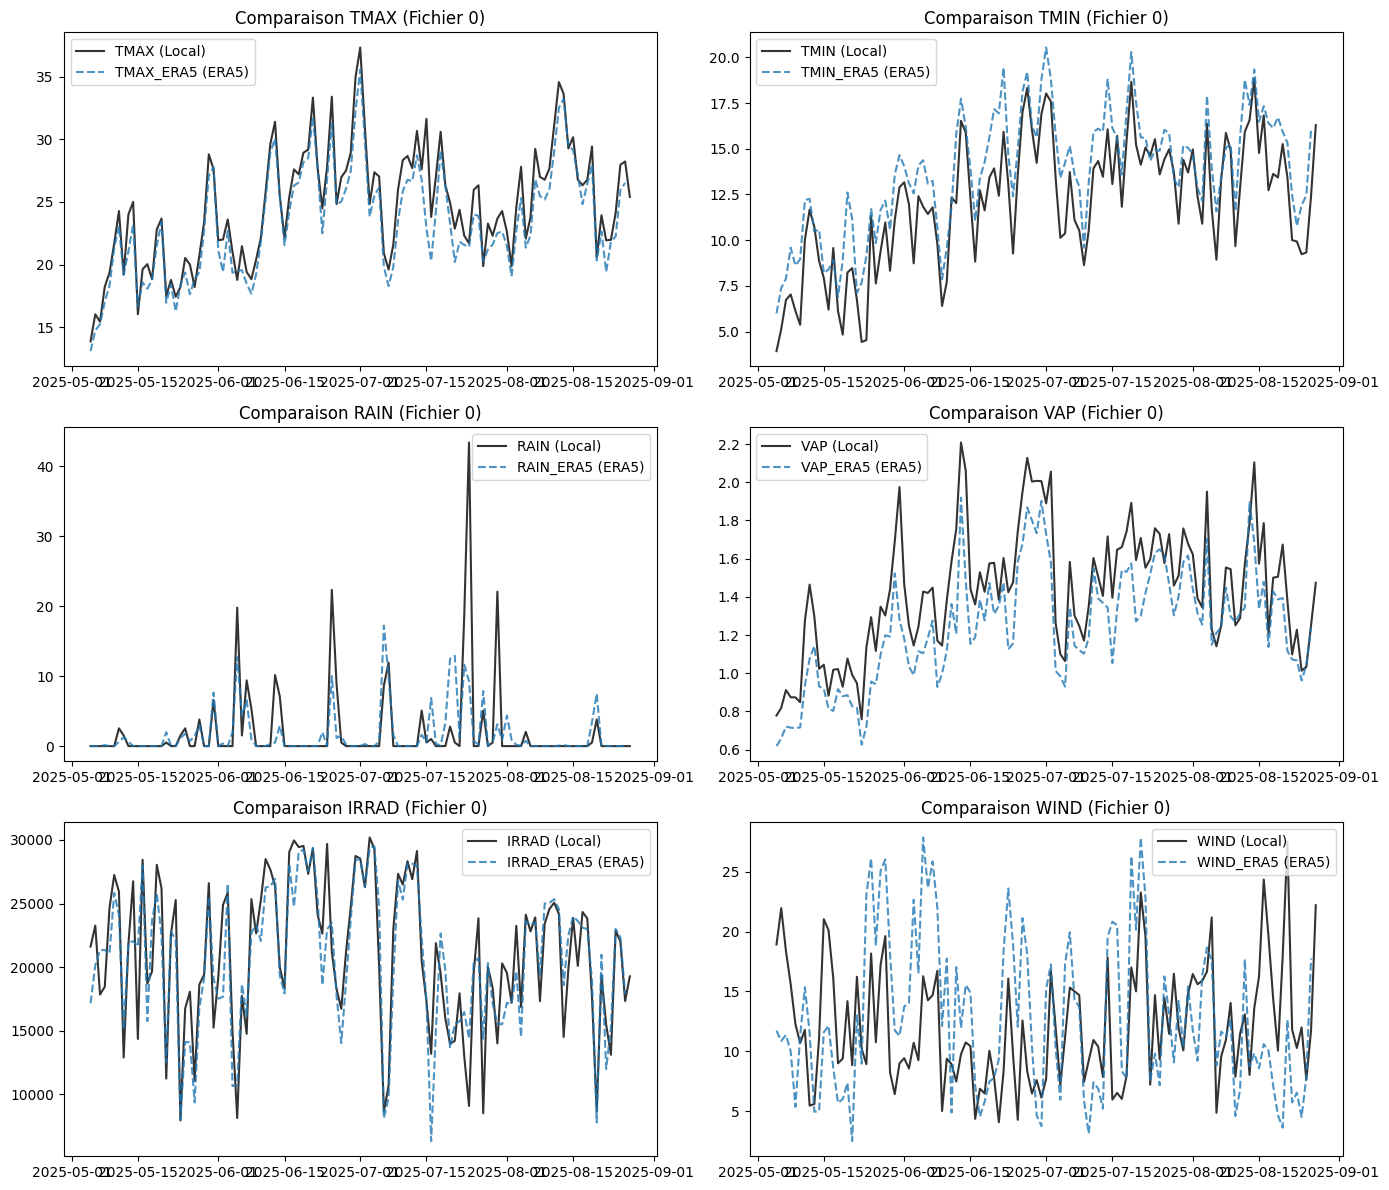

Téléchargement des données ERA5 de 2025-05-05 à 2025-08-28 pour 49.2822, 2.3713 ...

--- Comparaison (116 jours en commun pour Fichier 1) ---
• TMAX:  RMSE = 1.68 | MAE = 1.33 | Biais = 1.27 (Local - ERA5)
• TMIN:  RMSE = 2.13 | MAE = 1.83 | Biais = -1.75 (Local - ERA5)
• RAIN:  RMSE = 4.61 | MAE = 1.70 | Biais = 0.37 (Local - ERA5)
• VAP:  RMSE = 0.23 | MAE = 0.19 | Biais = 0.19 (Local - ERA5)
• IRRAD:  RMSE = 2726.14 | MAE = 2053.74 | Biais = 463.32 (Local - ERA5)
• WIND:  RMSE = 6.45 | MAE = 5.30 | Biais = -0.64 (Local - ERA5)


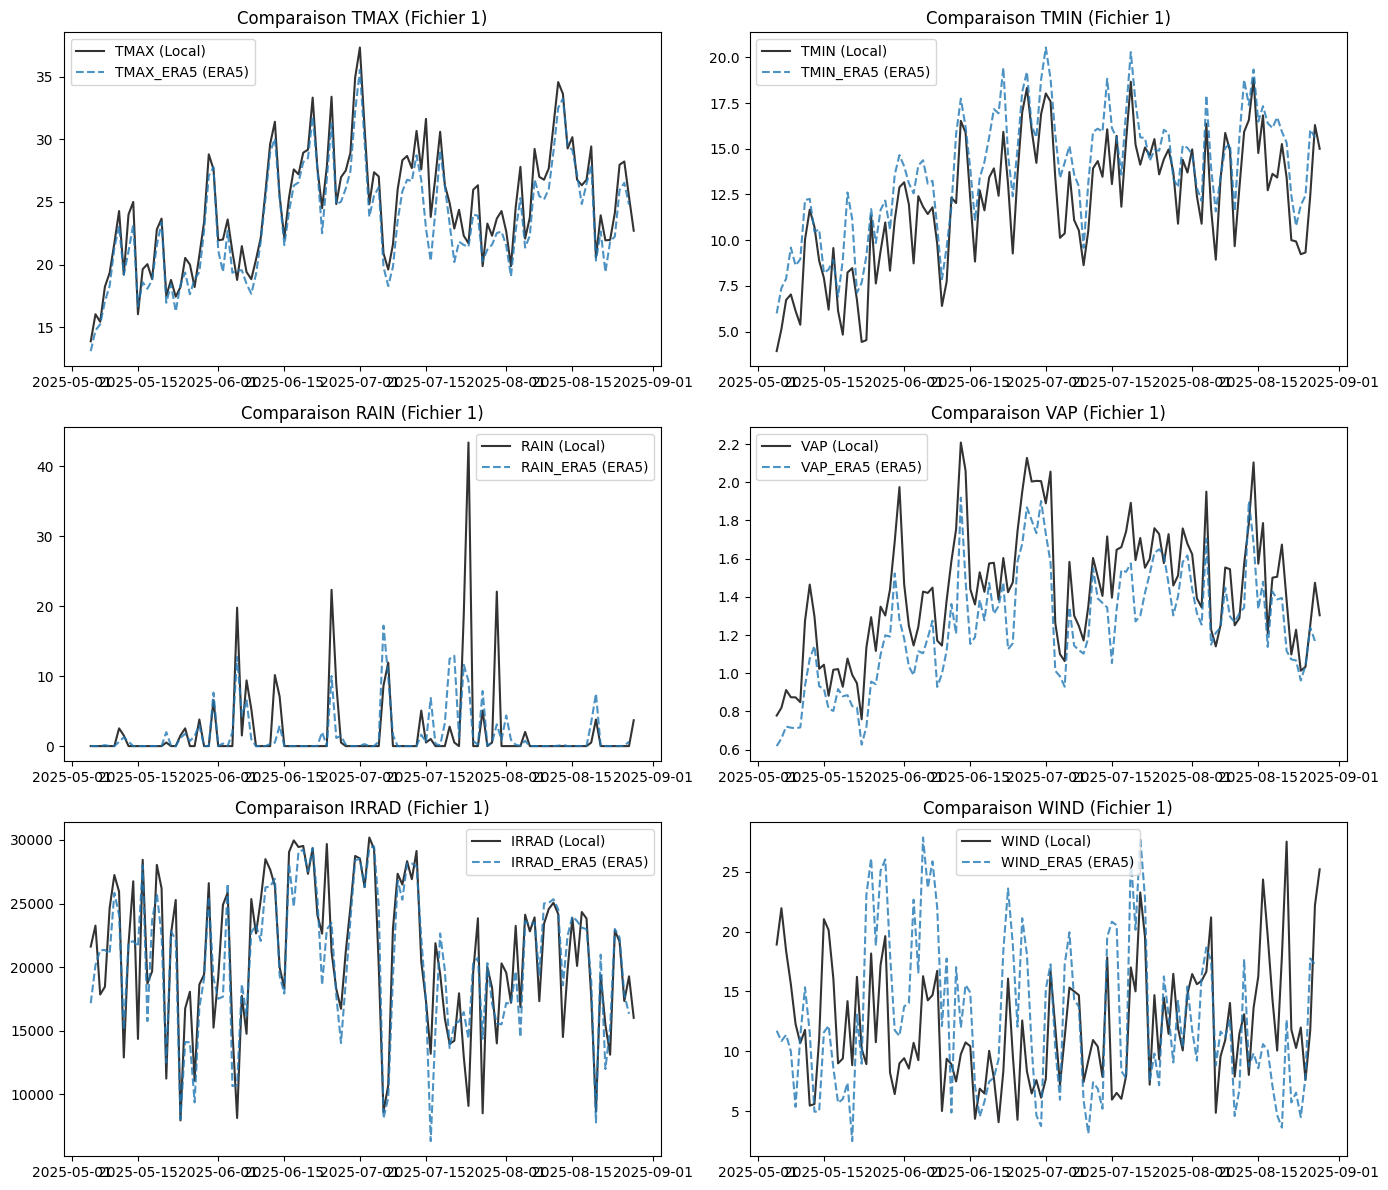

Téléchargement des données ERA5 de 2025-05-05 à 2025-08-27 pour 49.2822, 2.3713 ...

--- Comparaison (115 jours en commun pour Fichier 2) ---
• TMAX:  RMSE = 1.69 | MAE = 1.33 | Biais = 1.27 (Local - ERA5)
• TMIN:  RMSE = 2.14 | MAE = 1.84 | Biais = -1.77 (Local - ERA5)
• RAIN:  RMSE = 4.63 | MAE = 1.71 | Biais = 0.38 (Local - ERA5)
• VAP:  RMSE = 0.23 | MAE = 0.19 | Biais = 0.19 (Local - ERA5)
• IRRAD:  RMSE = 2724.16 | MAE = 2045.93 | Biais = 441.57 (Local - ERA5)
• WIND:  RMSE = 6.46 | MAE = 5.30 | Biais = -0.69 (Local - ERA5)


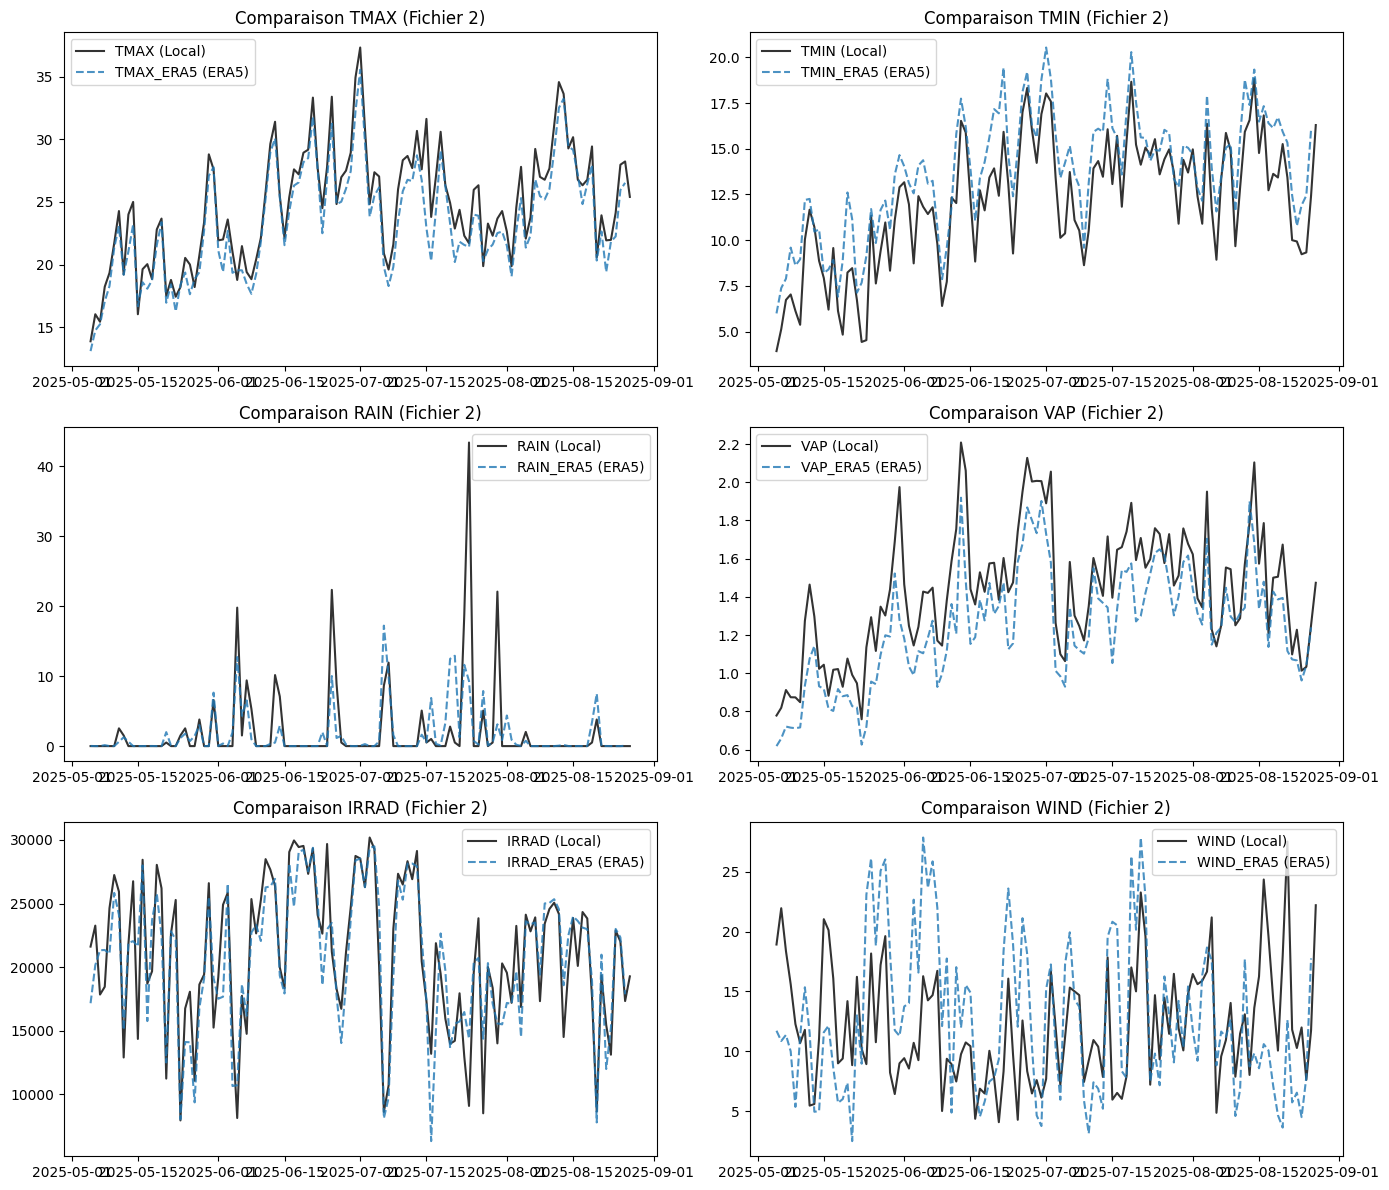

Téléchargement des données ERA5 de 2025-05-05 à 2025-08-27 pour 49.2822, 2.3713 ...

--- Comparaison (115 jours en commun pour Fichier 3) ---
• TMAX:  RMSE = 1.69 | MAE = 1.33 | Biais = 1.27 (Local - ERA5)
• TMIN:  RMSE = 2.14 | MAE = 1.84 | Biais = -1.77 (Local - ERA5)
• RAIN:  RMSE = 4.63 | MAE = 1.71 | Biais = 0.38 (Local - ERA5)
• VAP:  RMSE = 0.23 | MAE = 0.19 | Biais = 0.19 (Local - ERA5)
• IRRAD:  RMSE = 2724.16 | MAE = 2045.93 | Biais = 441.57 (Local - ERA5)
• WIND:  RMSE = 6.46 | MAE = 5.30 | Biais = -0.69 (Local - ERA5)


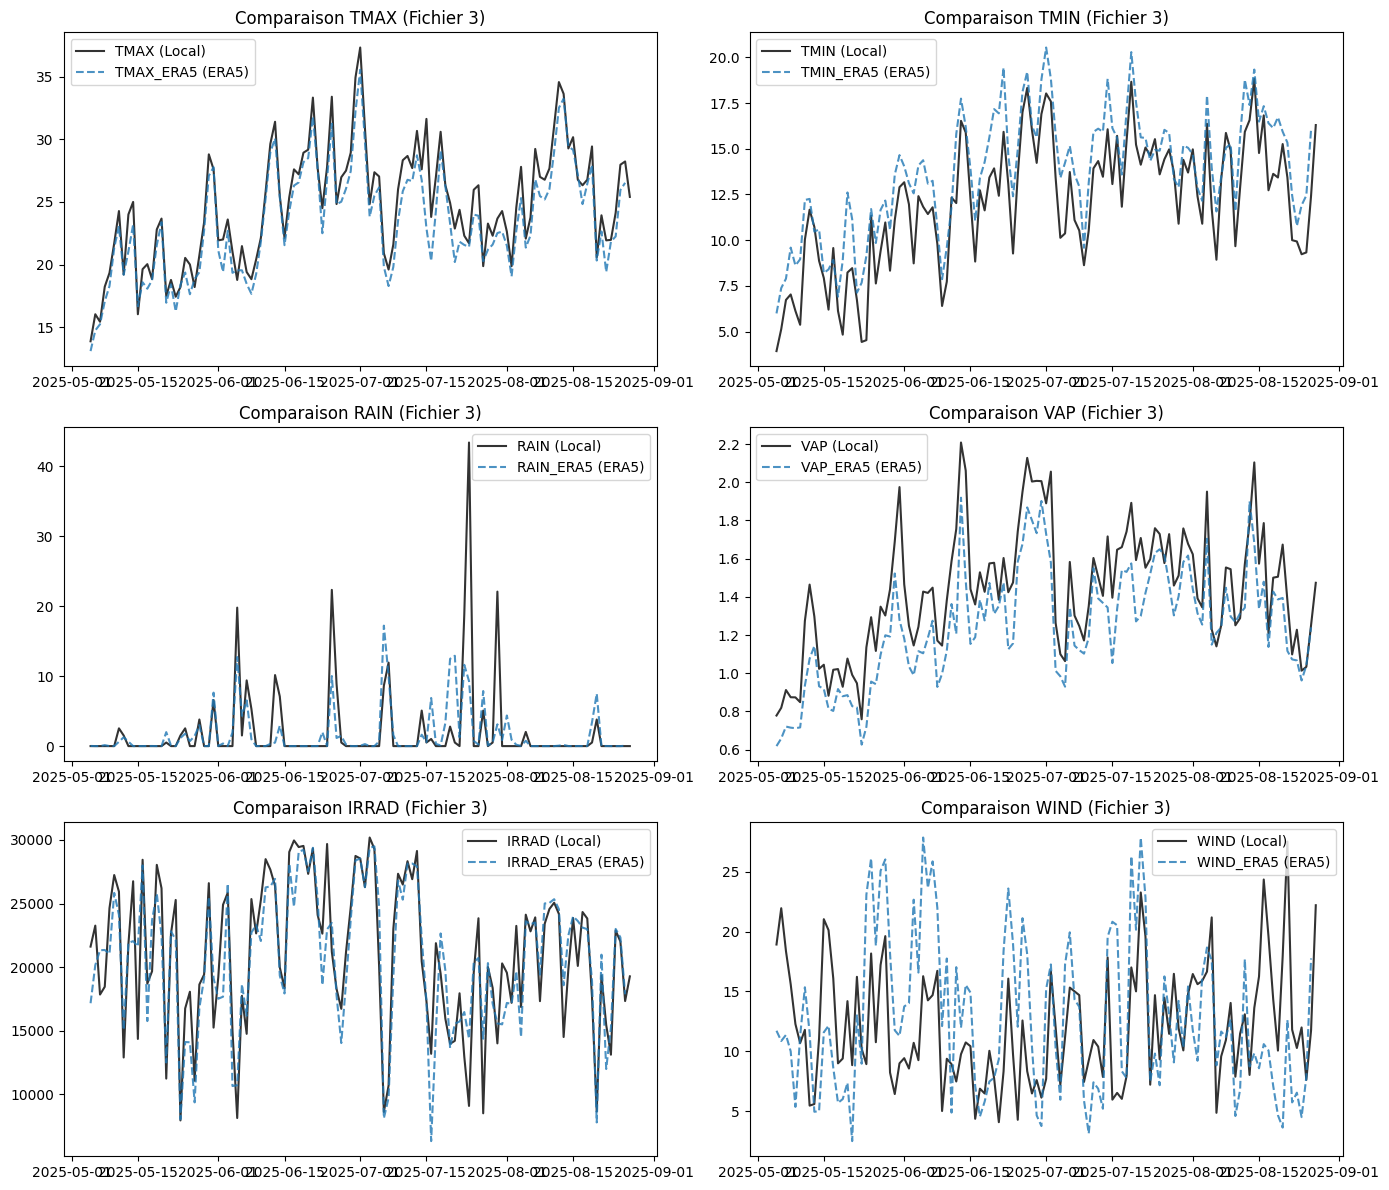

Téléchargement des données ERA5 de 2025-05-05 à 2025-08-27 pour 49.2822, 2.3713 ...

--- Comparaison (115 jours en commun pour Fichier 4) ---
• TMAX:  RMSE = 1.69 | MAE = 1.33 | Biais = 1.27 (Local - ERA5)
• TMIN:  RMSE = 2.14 | MAE = 1.84 | Biais = -1.77 (Local - ERA5)
• RAIN:  RMSE = 4.63 | MAE = 1.71 | Biais = 0.38 (Local - ERA5)
• VAP:  RMSE = 0.23 | MAE = 0.19 | Biais = 0.19 (Local - ERA5)
• IRRAD:  RMSE = 2724.16 | MAE = 2045.93 | Biais = 441.57 (Local - ERA5)
• WIND:  RMSE = 6.46 | MAE = 5.30 | Biais = -0.69 (Local - ERA5)


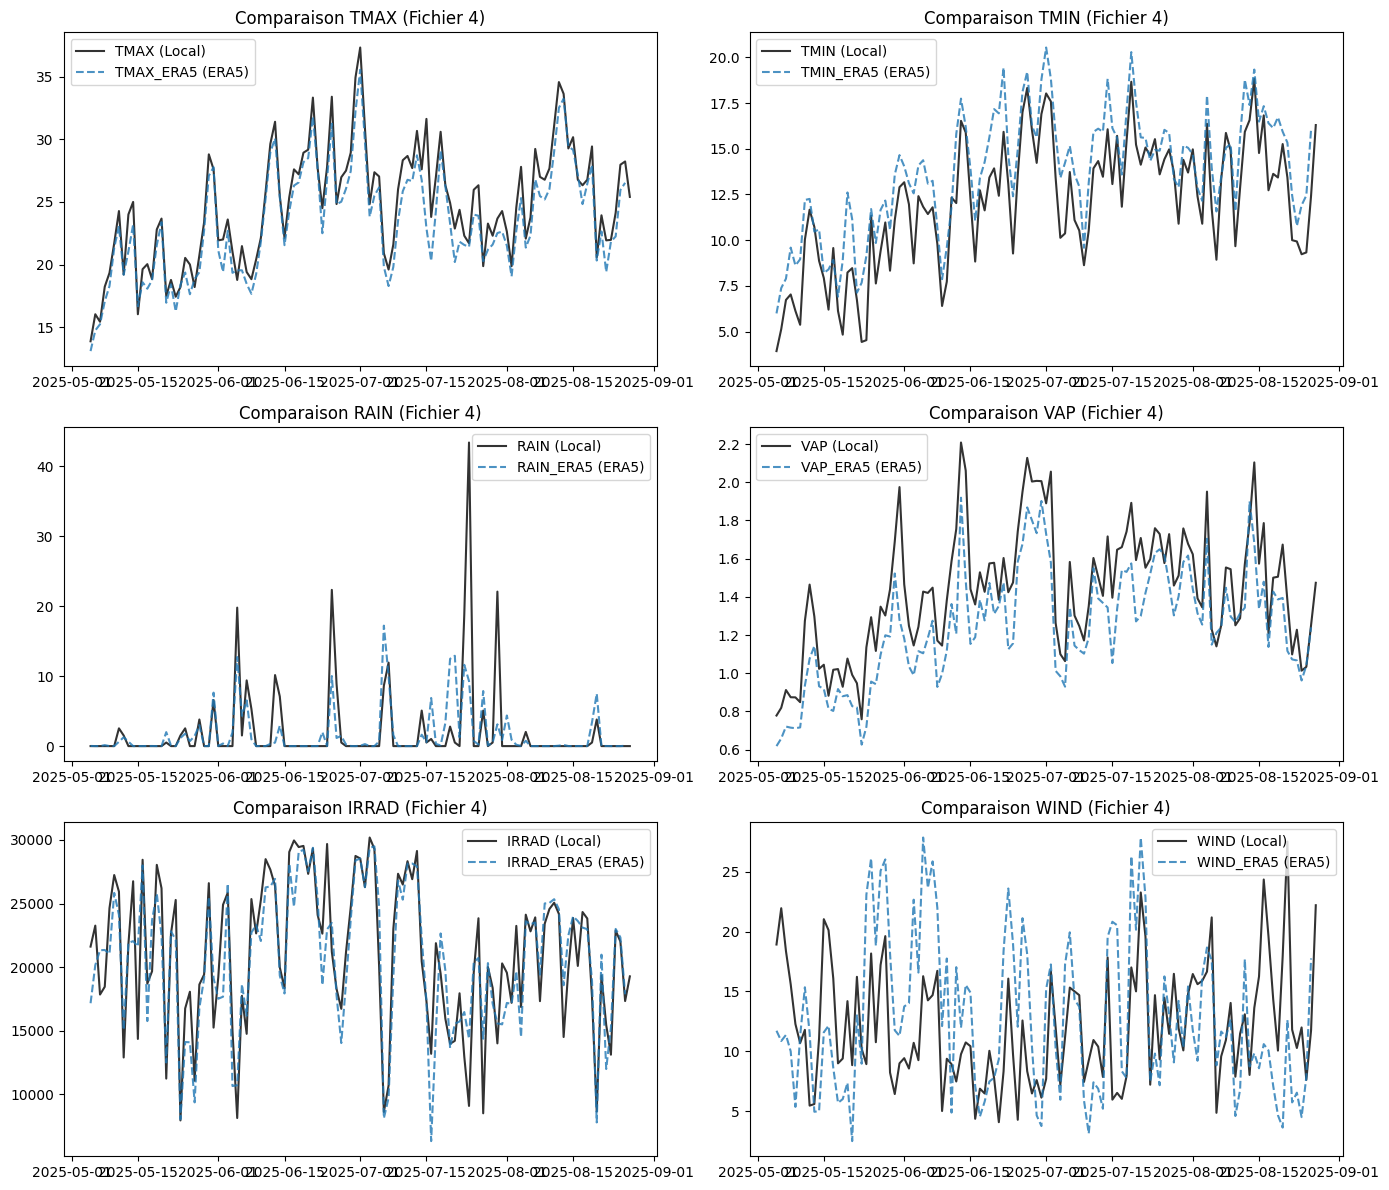

Téléchargement des données ERA5 de 2025-05-07 à 2025-08-27 pour 49.2822, 2.3713 ...

--- Comparaison (113 jours en commun pour Fichier 5) ---
• TMAX:  RMSE = 1.70 | MAE = 1.34 | Biais = 1.28 (Local - ERA5)
• TMIN:  RMSE = 2.14 | MAE = 1.83 | Biais = -1.76 (Local - ERA5)
• RAIN:  RMSE = 4.67 | MAE = 1.74 | Biais = 0.39 (Local - ERA5)
• VAP:  RMSE = 0.23 | MAE = 0.19 | Biais = 0.19 (Local - ERA5)
• IRRAD:  RMSE = 2700.05 | MAE = 2014.95 | Biais = 381.94 (Local - ERA5)
• WIND:  RMSE = 6.39 | MAE = 5.24 | Biais = -0.86 (Local - ERA5)


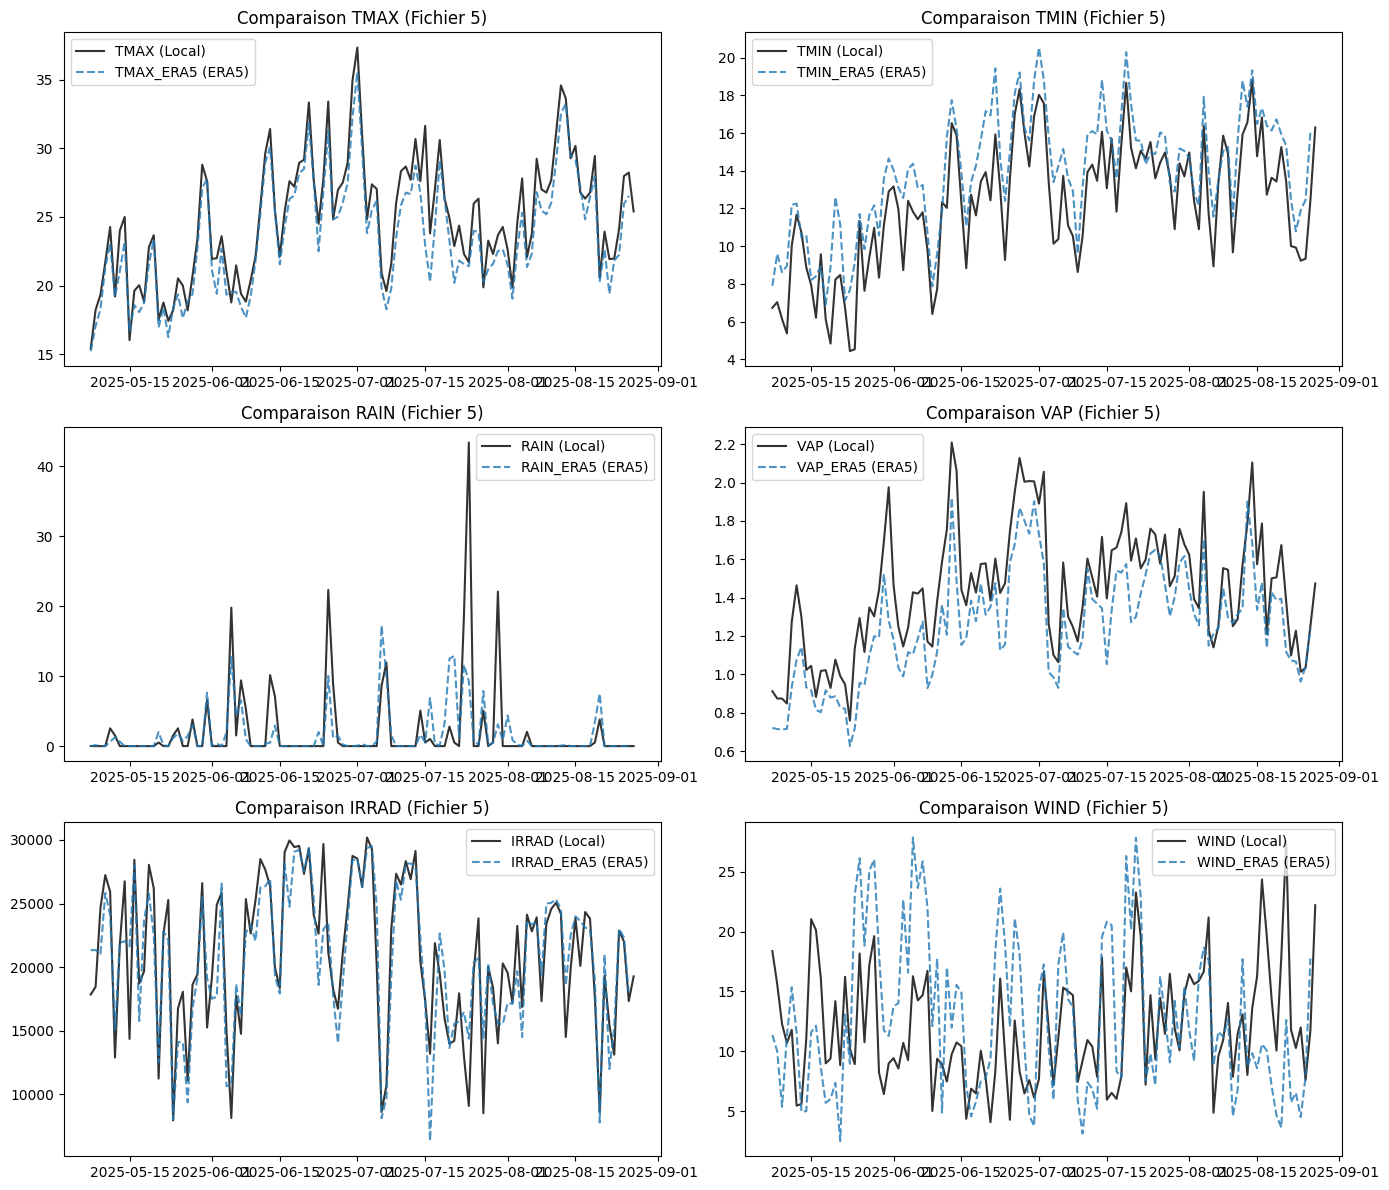

In [80]:
# ============================================================
# TEST ON GRANDVILLERS DATA WITH GRANDVILLERS DATASET
# ============================================================

# Réinitialiser les colonnes de features pour les tests (avec RAIN)
TARGET_COL = "soil_moisture"
DATE_COL = "DateTime"

# 1. Charger les données de test Grandvillers
project_path = '/content/gdrive/My Drive/Grandvillers/Grandvillers/Grandvillers_satellites'
test_list_local = Get_Grandvillers_data(project_path)

# 2. Préparer directement la version de test ERA5 pour chaque fichier
test_list_era5 = []
print("--- PRÉPARATION DU JEU DE TEST ERA5 ---")
for i, df in enumerate(test_list_local):
    df_substituted = prepare_era5_dataset(df, display_name=f"Fichier {i}")
    test_list_era5.append(df_substituted)

In [81]:
# ============================================================
# 3. Itérer sur chaque modèle entrainé et l'évaluer en comparaison
# ============================================================

c = 0  # On teste par défaut le premier bloc validé croisé de chaque modèle (chunk_0)

for depth in DEPTHS:
    for lookback in LOOKBACK:
        for horizon in HORIZONS:
            for nb_window in NB_WINDOWS : 
                for m in MODELS:
                    
                    features_name = feature_name_path(RESULTS_CSV_PATH, FEATURE_COLS)

                    # Mise à jour du chemin pour suivre l'architecture "Spatial Block Cross-Validation"
                    model_dir = os.path.join(drive_dir,  features_name, f"depth_{depth}", f"lookback_{lookback}", 
                                             f"horizon_{horizon}", f"nbwindows_{nb_window}", f"model_{m}", f"trial_{c}")
                    
                    if not os.path.exists(model_dir):
                        print(f"Model directory not found: {model_dir}")
                        continue

                    print(f"\n=======================================================")
                    print(f"Evaluation Grandvillers : D={depth}, LB={lookback}, H={horizon}, NB={nb_window}, Modèle={m}")
                    print(f"Dossier du bloc exploité: trial_{c} -> {model_dir}")
                    print(f"=======================================================\n")

                    model, scaler_x, scaler_y = load_saved_model_and_scalers(
                        model_dir, 
                        m, 
                        lookback, 
                        horizon, 
                        len(FEATURE_COLS)
                    )

                    if model is None:
                        continue
                    
                    run_comparative_evaluation(
                        model, scaler_x, scaler_y, 
                        test_list_local, test_list_era5, 
                        model_dir, 
                        lookback, 
                        horizon, 
                        depth,
                        nb_windows=nb_window,
                        chunk=c,
                        model_name=m
                    )


Evaluation Grandvillers : D=0.1, LB=7, H=7, NB=250, Modèle=lstm
Dossier du bloc exploité: trial_0 -> /content/gdrive/MyDrive/NIFA_Download/outputs/csv_meteo_and_soil/features_3/depth_0.1/lookback_7/horizon_7/nbwindows_250/model_lstm/trial_0



/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 28 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


[Fichier 0 - LOCAL] MAE=0.028633 RMSE=0.035432 MAPE=11.74%
[Fichier 0 - ERA5 ] MAE=0.028635 RMSE=0.035433 MAPE=11.74%
[Fichier 1 - LOCAL] MAE=0.049981 RMSE=0.051797 MAPE=19.57%
[Fichier 1 - ERA5 ] MAE=0.049983 RMSE=0.051799 MAPE=19.57%
[Fichier 2 - LOCAL] MAE=0.051677 RMSE=0.053701 MAPE=20.03%
[Fichier 2 - ERA5 ] MAE=0.051679 RMSE=0.053702 MAPE=20.03%
[Fichier 3 - LOCAL] MAE=0.048565 RMSE=0.052330 MAPE=18.82%
[Fichier 3 - ERA5 ] MAE=0.048567 RMSE=0.052332 MAPE=18.82%
[Fichier 4 - LOCAL] MAE=0.028219 RMSE=0.038389 MAPE=11.42%
[Fichier 4 - ERA5 ] MAE=0.028219 RMSE=0.038390 MAPE=11.42%
[Fichier 5 - LOCAL] MAE=0.047785 RMSE=0.050981 MAPE=18.65%
[Fichier 5 - ERA5 ] MAE=0.047787 RMSE=0.050982 MAPE=18.65%

--- MOYENNES GLOBALES GRANDVILLERS ---
Moyennes LOCAL -> MAE=0.042477, RMSE=0.047105, MAPE=16.70%
Moyennes ERA5  -> MAE=0.042478, RMSE=0.047107, MAPE=16.71%
✓ Résultat sauvegardé: GRANDVILLERS - mean_mae_local = 0.042477
✓ Résultat sauvegardé: GRANDVILLERS - mean_rmse_local = 0.047105
✓ Rés

/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 28 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


[Fichier 0 - LOCAL] MAE=0.069302 RMSE=0.073373 MAPE=31.25%
[Fichier 0 - ERA5 ] MAE=0.069340 RMSE=0.073409 MAPE=31.26%
[Fichier 1 - LOCAL] MAE=0.046273 RMSE=0.048910 MAPE=18.58%
[Fichier 1 - ERA5 ] MAE=0.046315 RMSE=0.048961 MAPE=18.59%
[Fichier 2 - LOCAL] MAE=0.044308 RMSE=0.047090 MAPE=17.63%
[Fichier 2 - ERA5 ] MAE=0.044346 RMSE=0.047129 MAPE=17.64%
[Fichier 3 - LOCAL] MAE=0.047432 RMSE=0.051656 MAPE=19.41%
[Fichier 3 - ERA5 ] MAE=0.047470 RMSE=0.051702 MAPE=19.42%
[Fichier 4 - LOCAL] MAE=0.074015 RMSE=0.080613 MAPE=35.12%
[Fichier 4 - ERA5 ] MAE=0.074053 RMSE=0.080651 MAPE=35.14%
[Fichier 5 - LOCAL] MAE=0.048192 RMSE=0.051732 MAPE=19.64%
[Fichier 5 - ERA5 ] MAE=0.048226 RMSE=0.051776 MAPE=19.65%

--- MOYENNES GLOBALES GRANDVILLERS ---
Moyennes LOCAL -> MAE=0.054920, RMSE=0.058896, MAPE=23.60%
Moyennes ERA5  -> MAE=0.054958, RMSE=0.058938, MAPE=23.62%
✓ Résultat sauvegardé: GRANDVILLERS - mean_mae_local = 0.05492
✓ Résultat sauvegardé: GRANDVILLERS - mean_rmse_local = 0.058896
✓ Résu

/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 28 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


[Fichier 0 - LOCAL] MAE=0.045930 RMSE=0.051314 MAPE=21.03%
[Fichier 0 - ERA5 ] MAE=0.045933 RMSE=0.051317 MAPE=21.03%
[Fichier 1 - LOCAL] MAE=0.023209 RMSE=0.026851 MAPE=9.46%
[Fichier 1 - ERA5 ] MAE=0.023211 RMSE=0.026853 MAPE=9.46%
[Fichier 2 - LOCAL] MAE=0.021494 RMSE=0.025218 MAPE=8.67%
[Fichier 2 - ERA5 ] MAE=0.021496 RMSE=0.025219 MAPE=8.67%
[Fichier 3 - LOCAL] MAE=0.025612 RMSE=0.030698 MAPE=10.66%
[Fichier 3 - ERA5 ] MAE=0.025613 RMSE=0.030698 MAPE=10.66%
[Fichier 4 - LOCAL] MAE=0.051439 RMSE=0.059489 MAPE=24.89%
[Fichier 4 - ERA5 ] MAE=0.051440 RMSE=0.059490 MAPE=24.89%
[Fichier 5 - LOCAL] MAE=0.025830 RMSE=0.030271 MAPE=10.69%
[Fichier 5 - ERA5 ] MAE=0.025831 RMSE=0.030272 MAPE=10.69%

--- MOYENNES GLOBALES GRANDVILLERS ---
Moyennes LOCAL -> MAE=0.032253, RMSE=0.037307, MAPE=14.23%
Moyennes ERA5  -> MAE=0.032254, RMSE=0.037308, MAPE=14.23%
✓ Résultat sauvegardé: GRANDVILLERS - mean_mae_local = 0.032253
✓ Résultat sauvegardé: GRANDVILLERS - mean_rmse_local = 0.037307
✓ Résulta

/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 28 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


[Fichier 0 - LOCAL] MAE=0.025020 RMSE=0.031529 MAPE=10.27%
[Fichier 0 - ERA5 ] MAE=0.025185 RMSE=0.031709 MAPE=10.34%
[Fichier 1 - LOCAL] MAE=0.043923 RMSE=0.046205 MAPE=17.18%
[Fichier 1 - ERA5 ] MAE=0.044167 RMSE=0.046449 MAPE=17.27%
[Fichier 2 - LOCAL] MAE=0.045582 RMSE=0.048115 MAPE=17.63%
[Fichier 2 - ERA5 ] MAE=0.045828 RMSE=0.048356 MAPE=17.73%
[Fichier 3 - LOCAL] MAE=0.042728 RMSE=0.046985 MAPE=16.50%
[Fichier 3 - ERA5 ] MAE=0.042973 RMSE=0.047219 MAPE=16.60%
[Fichier 4 - LOCAL] MAE=0.026570 RMSE=0.035727 MAPE=10.89%
[Fichier 4 - ERA5 ] MAE=0.026645 RMSE=0.035849 MAPE=10.91%
[Fichier 5 - LOCAL] MAE=0.041795 RMSE=0.045593 MAPE=16.26%
[Fichier 5 - ERA5 ] MAE=0.042042 RMSE=0.045829 MAPE=16.36%

--- MOYENNES GLOBALES GRANDVILLERS ---
Moyennes LOCAL -> MAE=0.037603, RMSE=0.042359, MAPE=14.79%
Moyennes ERA5  -> MAE=0.037807, RMSE=0.042569, MAPE=14.87%
✓ Résultat sauvegardé: GRANDVILLERS - mean_mae_local = 0.037603
✓ Résultat sauvegardé: GRANDVILLERS - mean_rmse_local = 0.042359
✓ Rés